In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.cluster import DBSCAN
import csv  #for importing 2020 borough population census data later

import geopandas as gpd #For mapping shooting locations
from shapely.geometry import Point

#Dataset csv's
shootings = "../data/Shootings_2006-Present_20260608_CLEANED.csv"
victims = "../data/Shooting_Victims_2006-Present_20260608.csv"
#May not include weather because, ideally, need weather for all 5 boroughs not just JFK airport
#weather = "../data/ncei_noaa_weather_JFK_international_airport_CLEANED.csv"

df_victims = pd.read_csv(victims)
df_shootings = pd.read_csv(shootings)
df_shootings.head(3)

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night
0,212200405,04/20/2020,19:36:00,BROOKLYN,OUTSIDE,79,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000301.0,192923.0,40.696199,-73.942118,2020-04-20 19:36:00,Monday,Day
1,139554478,11/07/2014,03:20:00,BRONX,INSIDE,42,0.0,DWELLING,PVT HOUSE,1012185.0,241494.0,40.829485,-73.899059,2014-11-07 03:20:00,Friday,Night
2,167619814,08/01/2017,00:35:00,BRONX,OUTSIDE,47,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1030360.0,261043.0,40.883065,-73.833250,2017-08-01 00:35:00,Tuesday,Night


In [2]:
#datetime is most likely a string (needs to be converted back to datetime)
df_shootings.info()

<class 'pandas.DataFrame'>
RangeIndex: 24127 entries, 0 to 24126
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INCIDENT_KEY        24127 non-null  int64  
 1   OCCUR_DATE          24127 non-null  str    
 2   OCCUR_TIME          24127 non-null  str    
 3   BORO                24127 non-null  str    
 4   LOC_OF_OCCUR_DESC   24127 non-null  str    
 5   PRECINCT            24127 non-null  int64  
 6   JURISDICTION_CODE   24125 non-null  float64
 7   LOC_CLASSFCTN_DESC  24094 non-null  str    
 8   LOCATION_DESC       9693 non-null   str    
 9   X_COORD_CD          24126 non-null  float64
 10  Y_COORD_CD          24126 non-null  float64
 11  Latitude            24126 non-null  float64
 12  Longitude           24126 non-null  float64
 13  datetime            24127 non-null  str    
 14  day_of_week         24127 non-null  str    
 15  day_or_night        24127 non-null  str    
dtypes: float64(5), 

In [3]:
#need to convert "datetime" into a datetime again 
df_shootings['datetime'] = pd.to_datetime(df_shootings['datetime'])


## Remove Unwanted Columns from df_shootings Dataset

In [4]:
#Already have a datetime column so will remove OCCUR_DATE	OCCUR_TIME
#X_COORD_CD	Y_COORD_CD may be useful for clustering analysis i.e. DBSCAN  - these datapoints (X_COORD_CD, Y_COORD_CD) provide an easy way to judge distances between shootings in feet 
df_shootings.drop(columns=['OCCUR_DATE', 'OCCUR_TIME'], inplace=True)
df_shootings.head()

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night
0,212200405,BROOKLYN,OUTSIDE,79,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000301.0,192923.0,40.696199,-73.942118,2020-04-20 19:36:00,Monday,Day
1,139554478,BRONX,INSIDE,42,0.0,DWELLING,PVT HOUSE,1012185.0,241494.0,40.829485,-73.899059,2014-11-07 03:20:00,Friday,Night
2,167619814,BRONX,OUTSIDE,47,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1030360.0,261043.0,40.883065,-73.833250,2017-08-01 00:35:00,Tuesday,Night
3,212516311,BRONX,OUTSIDE,46,0.0,STREET,NaN,1009085.0,248078.0,40.847565,-73.910236,2020-04-29 15:30:00,Wednesday,Day
4,270150948,QUEENS,OUTSIDE,108,0.0,STREET,NaN,1004925.0,209948.0,40.742919,-73.925390,2023-06-20 23:41:00,Tuesday,Night


## Did a shooting result in at least one murder?

- Need to group INCIDENT_KEY in df_victims and aggregate to find a count of victims and of deaths/murders 

In [5]:
#Just a quick peak at df_victims dataset to see what we can use this for!
df_victims.head(3)

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG
0,299453927,299453927-1,25-44,MALE,BLACK,N
1,212336415,212336415-1,18-24,MALE,BLACK,N
2,280768895,280768895-1,25-44,MALE,BLACK,N


 - There are (or can be) multiple victims per shooting occurance. We can also sum the number of deaths per shooting incident. 

In [6]:
# Let's also see if there are any shooting incidents where no victims were recorded
# i.e. incident key exists in df_shootings but does not exist in df_victims.
missing = set(df_shootings['INCIDENT_KEY']) - set(df_victims['INCIDENT_KEY'])
len(missing)

0

- Okay, so all shootings in df_shootings have at least one recorded victim - This means that shootings were recorded if someone was at least injured. 

In [7]:
#Let's see if any incident keys that exist in df_victims but have no matching shooting record. 
#if so, we have "orphaned" victim rows - they reference an incident that, according to df_shootings, doesn't exist.
orphaned_keys = set(df_victims['INCIDENT_KEY']) - set(df_shootings['INCIDENT_KEY'])
df_victims[df_victims['INCIDENT_KEY'].isin(orphaned_keys)]

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG
11568,78019135,78019135-20239,25-44,MALE,BLACK HISPANIC,N
28911,203259656,NaN,NaN,NaN,NaN,NaN


- For some reason these shooting incidents {78019135, 203259656} have been removed or not properly recorded in the df_shootings dataset.
- For my purposes, I will exclude VICTIM_ID: 78019135-20239 because I cannot attach it to a date or a location
- I want to explore the change in shootings and killings in each 5 boroughs pre, during and post COVID-19 pandemic (this also coincided with George Floyd murder 25-May-2020 and resulting social unrest). I, also, want to focus on analyzing where rapid decline in shootings took place in the years after the pandemic.

In [8]:
#Removing the "orphaned" rows but keeping original df_victims dataframe untouched
df_victims_clean = df_victims[~df_victims['INCIDENT_KEY'].isin(orphaned_keys)]

In [9]:
#Because we can have multiple victims per shooting incident, we need to groupby('INCIDENT_KEY') in df_victims_clean

#create True or False values to make aggregation easier
df_victims_clean['is_death'] = df_victims_clean['STAT_MURDER_FLG'] == 'Y' #if Y then 'True'

incident_summary = df_victims_clean.groupby('INCIDENT_KEY').agg(
    n_victims = ('VICTIM_ID', 'count'),
    n_deaths  = ('is_death', 'sum')
).reset_index()

incident_summary.head(5)
    

,INCIDENT_KEY,n_victims,n_deaths
0,9953245,1,0
1,9953246,1,0
2,9953247,3,0
3,9953248,1,0
4,9953249,1,1


In [10]:
#checking this process has worked!
df_victims_clean.nsmallest(7, 'INCIDENT_KEY')

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG,is_death
7985,9953245,9953245-8156,<18,MALE,BLACK,N,False
1507,9953246,9953246-8158,18-24,MALE,WHITE HISPANIC,N,False
5490,9953247,9953247-8160,18-24,MALE,BLACK,N,False
5491,9953247,9953247-8161,18-24,MALE,BLACK,N,False
5492,9953247,9953247-8162,18-24,MALE,BLACK,N,False
13,9953248,9953248-8163,18-24,MALE,BLACK,N,False
8476,9953249,9953249-8164,25-44,MALE,BLACK,Y,True


In [11]:
#also,INCIDENT_KEY should now be unique for incident_summary
incident_summary['INCIDENT_KEY'].duplicated().sum()

np.int64(0)

In [12]:
#Now, I can merge incident summary with df_shootings
df_shootings = df_shootings.merge(incident_summary, on='INCIDENT_KEY', how='left')
df_shootings.head()


,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths
0,212200405,BROOKLYN,OUTSIDE,79,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000301.0,192923.0,40.696199,-73.942118,2020-04-20 19:36:00,Monday,Day,1,1
1,139554478,BRONX,INSIDE,42,0.0,DWELLING,PVT HOUSE,1012185.0,241494.0,40.829485,-73.899059,2014-11-07 03:20:00,Friday,Night,1,0
2,167619814,BRONX,OUTSIDE,47,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1030360.0,261043.0,40.883065,-73.833250,2017-08-01 00:35:00,Tuesday,Night,1,0
3,212516311,BRONX,OUTSIDE,46,0.0,STREET,NaN,1009085.0,248078.0,40.847565,-73.910236,2020-04-29 15:30:00,Wednesday,Day,1,0
4,270150948,QUEENS,OUTSIDE,108,0.0,STREET,NaN,1004925.0,209948.0,40.742919,-73.925390,2023-06-20 23:41:00,Tuesday,Night,1,0


In [13]:
#Checking for NaN in n_victims and n_deaths
print(f"Number of null or missing values in n_victims: {df_shootings['n_victims'].isna().sum()}")
print(f"Number of null or missing values in n_deaths: {df_shootings['n_deaths'].isna().sum()}")

Number of null or missing values in n_victims: 0
Number of null or missing values in n_deaths: 0


In [14]:
#What's the max number of deaths in one shooting?
df_shootings.nlargest(5, 'n_deaths')

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths
17612,203676928,BROOKLYN,INSIDE,77,0.0,COMMERCIAL,BAR/NIGHT CLUB,1003550.0,185644.0,40.676214,-73.930422,2019-10-12 06:55:00,Saturday,Day,7,4
22991,310357834,MANHATTAN,INSIDE,18,0.0,COMMERCIAL,NaN,991647.0,215481.0,40.758127,-73.973301,2025-07-28 18:28:00,Monday,Day,5,4
1054,29479155,BROOKLYN,OUTSIDE,73,0.0,STREET,NaN,1008421.0,178716.0,40.657186,-73.912886,2007-06-06 23:57:00,Wednesday,Night,3,3
1215,28523999,QUEENS,INSIDE,105,0.0,DWELLING,PVT HOUSE,1057644.0,192456.0,40.694628,-73.735330,2007-04-18 11:40:00,Wednesday,Day,3,3
1928,27415044,MANHATTAN,INSIDE,6,0.0,COMMERCIAL,NaN,984277.0,205026.0,40.729434,-73.999904,2007-03-14 21:26:00,Wednesday,Night,3,3


In [15]:
#What's the max number of victims in one shooting?
df_shootings.nlargest(5, 'n_victims')

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths
22994,311327863,BROOKLYN,OUTSIDE,71,0.0,COMMERCIAL,BAR/NIGHT CLUB,995600.0,182496.0,40.667587,-73.959088,2025-08-17 03:27:00,Sunday,Night,14,3
18494,200331333,BROOKLYN,OUTSIDE,73,0.0,PLAYGROUND,NaN,1011786.0,178738.0,40.657237,-73.900758,2019-07-27 22:53:00,Saturday,Night,12,1
9672,80484245,QUEENS,OUTSIDE,113,0.0,DWELLING,PVT HOUSE,1040363.0,188626.0,40.684242,-73.797680,2011-08-27 00:40:00,Saturday,Night,11,0
20796,243566417,BROOKLYN,INSIDE,72,1.0,TRANSIT,NaN,983024.0,177659.0,40.654318,-74.004420,2022-04-12 08:26:00,Tuesday,Day,10,0
23311,231637053,QUEENS,OUTSIDE,115,0.0,STREET,NaN,1020765.0,213373.0,40.752269,-73.868208,2021-07-31 22:36:00,Saturday,Night,10,0


# Break Down of Shootings, Victims and Deaths

## Shootings and Deaths (Yearly Totals)

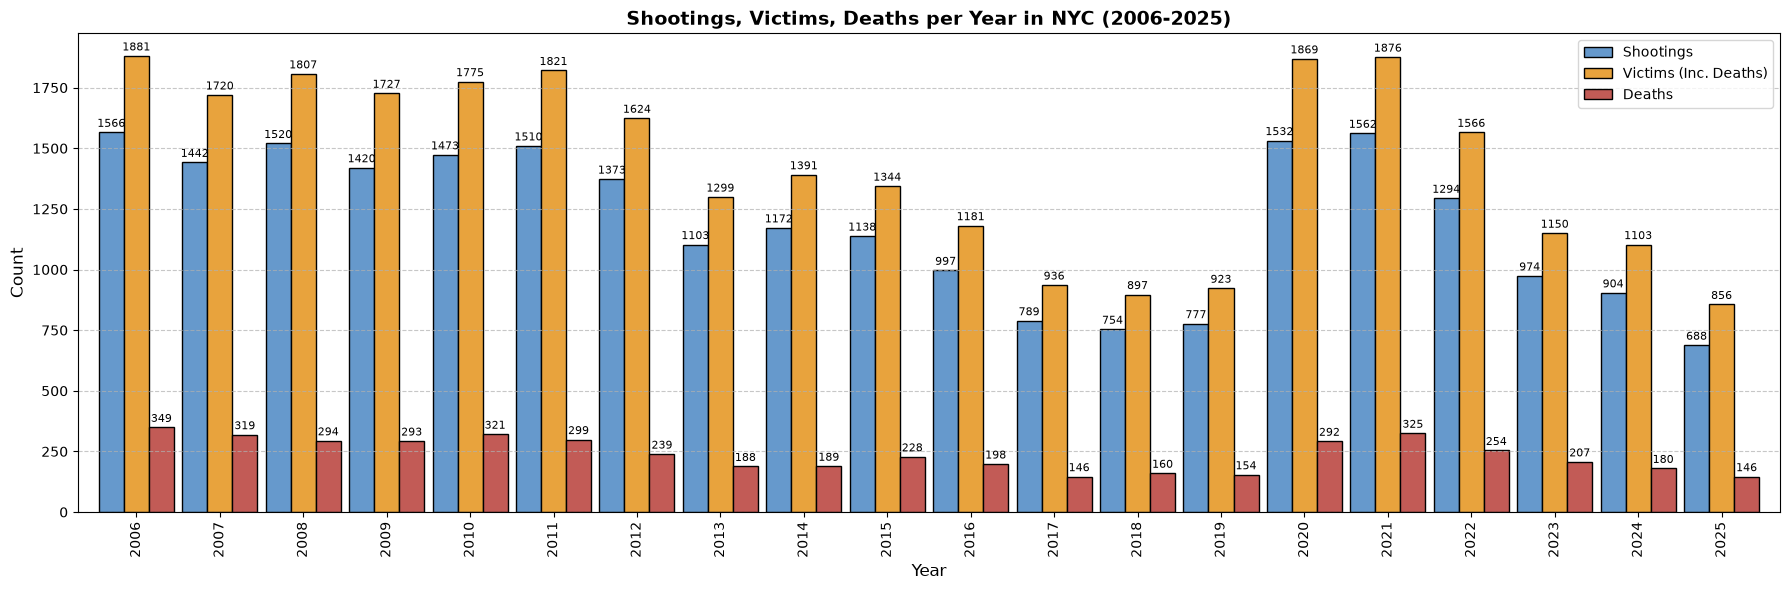

In [16]:
mask = df_shootings['datetime'].between('2006-01-01 00:00:00', '2025-12-31 23:59:59')
df_masked = df_shootings[mask].copy()
year = df_masked['datetime'].dt.to_period('Y')

summary = pd.DataFrame({
    'Shootings': df_masked.groupby(year).size(),
    'Victims (Inc. Deaths)': df_masked.groupby(year)['n_victims'].sum(),
    'Deaths': df_masked.groupby(year)['n_deaths'].sum()
}).sort_index()

ax = summary.plot(
    kind='bar',
    figsize=(18,6),
    color=['#6699CC', '#E8A33D', '#C25B56'],
    edgecolor='black',
    width=0.9
)
ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[2], fontsize=8, color='#000', padding=2)

plt.title("Shootings, Victims, Deaths per Year in NYC (2006-2025)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

- The orange Victims bar includes all those who were injured or died in a shooting - (Injuries + Deaths)
- The red Deaths bar is a subset of Victims rather than a separate, additional category
- Shootings remained consistent from 2006 to 2011 then gradually decreased from 2012 until 2020 and 2021 where they spiked higher than any time in the last 20 years
- The lowest shootings and deaths, city-wide, occured between the years 2017 and 2019 and 2025 following spike during pandemic and George Floyd protests


In [17]:
shooting_inc = round((summary.loc['2020', 'Shootings'] / summary.loc['2019', 'Shootings']) * 100.0, 1)
death_inc = round((summary.loc['2020', 'Deaths'] / summary.loc['2019', 'Deaths']) * 100.0, 1)
print(f"Between 2019 and 2020, there was a {shooting_inc}% increase in shootings city-wide in NYC.")
print(f"And, there was a {death_inc}% increase in deaths city-wide in NYC")

Between 2019 and 2020, there was a 197.2% increase in shootings city-wide in NYC.
And, there was a 189.6% increase in deaths city-wide in NYC


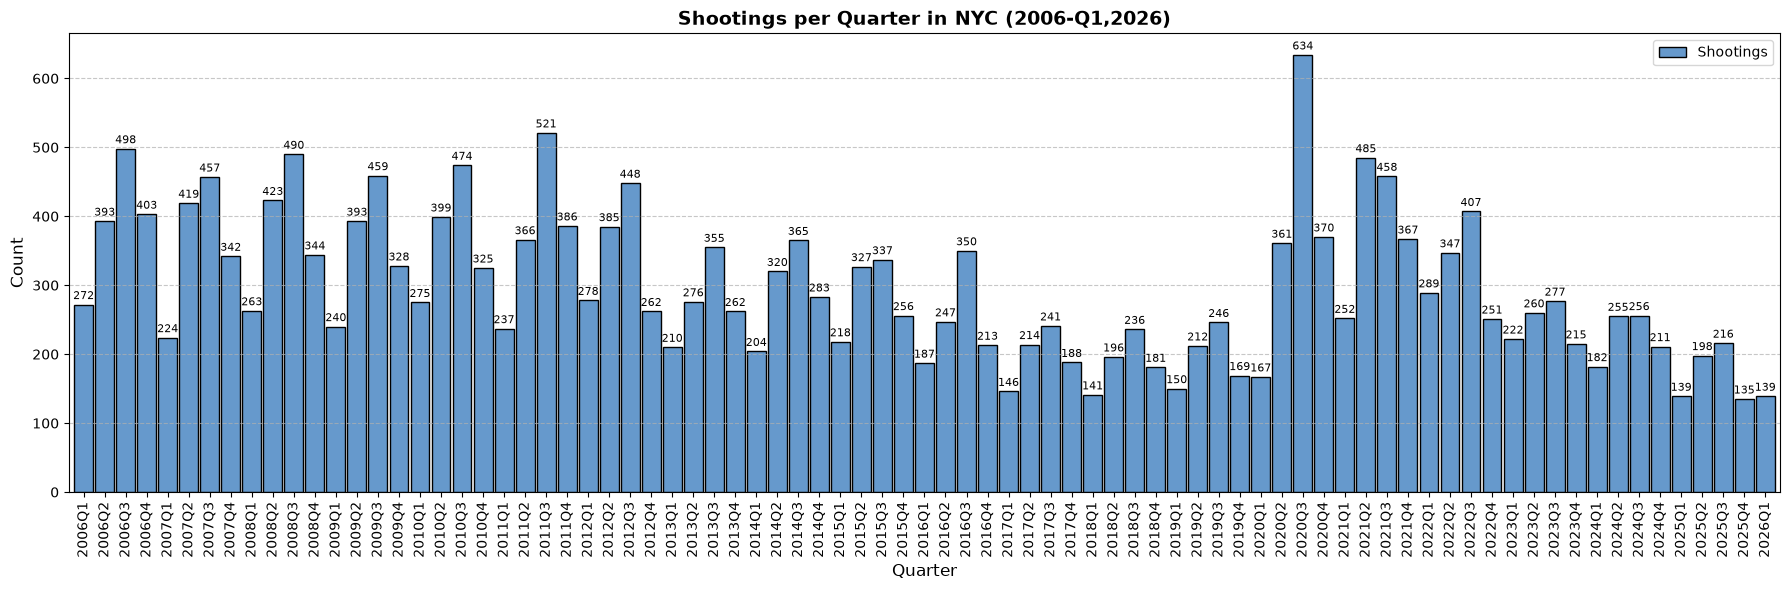

In [18]:
mask = df_shootings['datetime'].between('2006-01-01 00:00:00', '2026-03-31 23:59:59') 
df_masked = df_shootings[mask].copy()
quarter = df_masked['datetime'].dt.to_period('Q')

summary = pd.DataFrame({
    'Shootings': df_masked.groupby(quarter).size(),
    #'Victims (Inc. Deaths)': df_masked.groupby(quarter)['n_victims'].sum(),
    #'Deaths': df_masked.groupby(quarter)['n_deaths'].sum()
}).sort_index()

ax = summary.plot(
    kind='bar',
    figsize=(18,6),
    color=['#6699CC'],
    edgecolor='black',
    width=0.9
)
ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
#ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
#ax.bar_label(ax.containers[2], fontsize=8, color='#000', padding=2)

plt.title("Shootings per Quarter in NYC (2006-Q1,2026)", fontsize=14, fontweight='bold')
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

- We see a fairly consistent pattern here city-wide:
    - Over 20 years of data, Q1 consistently shows the lowest shooting occurance with only Q4 of 2025 matching Q1 of 2026
    - Q3 has the highest rate of shootings for 19 out of the 20 years with the exception of 2021 where Q2 had a slight increase over Q3 of the same year.

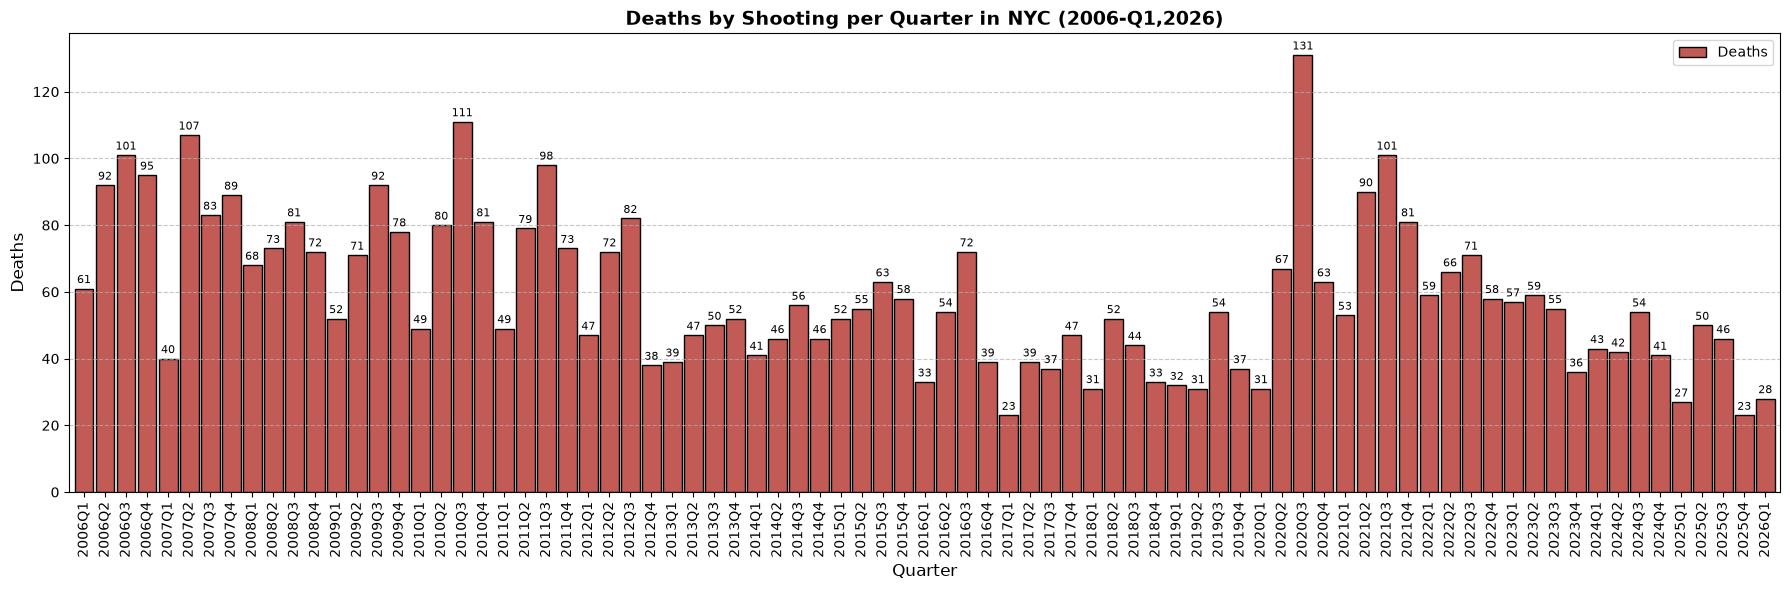

In [19]:
mask = df_shootings['datetime'].between('2006-01-01 00:00:00', '2026-03-31 23:59:59')
df_masked = df_shootings[mask].copy()
quarter = df_masked['datetime'].dt.to_period('Q')

summary = pd.DataFrame({
    #'Shootings': df_masked.groupby(quarter).size(),
    #'Victims (Inc. Deaths)': df_masked.groupby(quarter)['n_victims'].sum(),
    'Deaths': df_masked.groupby(quarter)['n_deaths'].sum()
}).sort_index()

ax = summary.plot(
    kind='bar',
    figsize=(18,6),
    color=['#C25B56'],
    edgecolor='black',
    width=0.9
)
ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
#ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
#ax.bar_label(ax.containers[2], fontsize=8, color='#000', padding=2)

plt.title("Deaths by Shooting per Quarter in NYC (2006-Q1,2026)", fontsize=14, fontweight='bold')
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Deaths", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

- Deaths show a more random or unpredictible pattern compared to shooting incidents probably due to more factors influencing these events like proximity of shooter to victim, number of shots fired, weapon used, proximity to hospital etc.
- But, there tends to be more death by shooting city-wide in Q3 and a reduction in Q1.
- in 20 years of data, the highest death count was in Q3 of 2020 where 131 people died as a result of gun violence in NYC

## Shootings and Deaths by Borough (Raw Counts)
### Which Borough Has More Shootings (Pre, During and Post COVID Pandemic)?

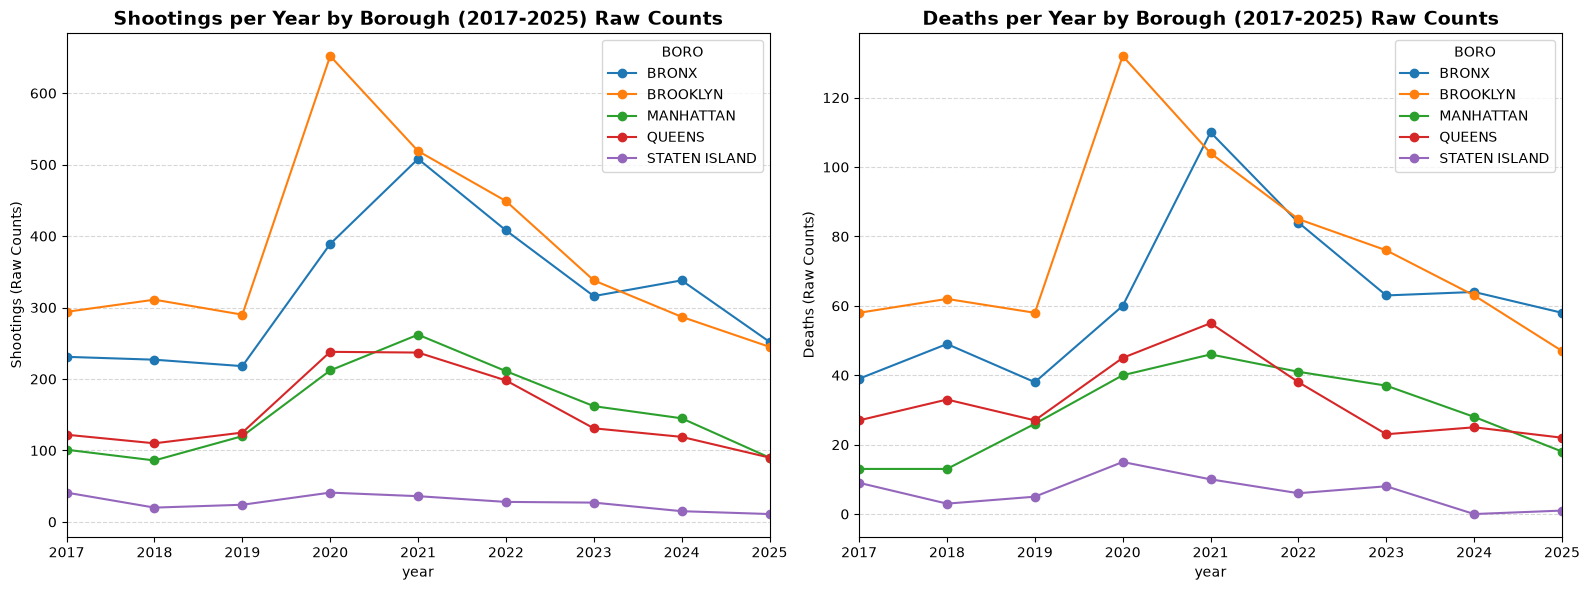

In [20]:
mask = df_shootings['datetime'].between('2017-01-01 00:00:00', '2025-12-31 23:59:59') 
df_masked = df_shootings[mask].copy()
df_masked['year'] = df_masked['datetime'].dt.to_period('Y')

grouped = df_masked.groupby(['BORO', 'year']).agg(
    Shootings=('INCIDENT_KEY', 'size'),
    Victims=('n_victims', 'sum'),
    Deaths=('n_deaths', 'sum')
).reset_index()

pivot_shootings = grouped.pivot(index='year', columns='BORO', values='Shootings')
pivot_deaths = grouped.pivot(index='year', columns='BORO', values='Deaths')

fig, axs = plt.subplots(1, 2, figsize=(16,6))

pivot_shootings.plot(kind='line', ax=axs[0], marker='o')
axs[0].set_title("Shootings per Year by Borough (2017-2025) Raw Counts", fontsize=14, fontweight='bold')
axs[0].set_ylabel("Shootings (Raw Counts)")
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

pivot_deaths.plot(kind='line', ax=axs[1], marker='o')
axs[1].set_title("Deaths per Year by Borough (2017-2025) Raw Counts", fontsize=14, fontweight='bold')
axs[1].set_ylabel("Deaths (Raw Counts)")
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

- Looking at raw counts, (Not taking into account population sizes), we can see:
    -  every borough in NYC saw an increase in shootings in 2020 compared to the previous year; with Brooklyn, Queens and Staten Island peaking in 2020 before declining and The Bronx and Manhatten continuing to climb into 2021 before decline in the years after.
- Because we only have raw counts here and not population size per year, it's not possible to conclude why shootings and deaths reduced from 2020/2021 to 2025 - could it be due to a population decline as well as other confounding variables etc.
- But, We will have a closer look at the shooting rate per bourough with 2020 census data from: https://popfactfinder.planning.nyc.gov/ 

## Shootings Per Capita
### Shooting Rate per Borough in 2020

- shootings per 100'000 people from 2020 decennial census count.
- Which borough was more dangerous in 2020?

In [21]:
def extract_borough_stats(borough, filepath):
    with open(filepath, newline='') as f:
        rows = list(csv.reader(f))
    
    stats = {'BORO': borough}
    for row in rows:
        if not row:
            continue
        label=row[0].strip()
        if label == 'Total Population':
            stats['pop_2020'] = int(str(row[1]).replace(',','').strip())
        elif label == 'Population per acre':
            stats['pop_density_2020'] = float(str(row[1]).strip())
    return stats

#This data originates from https://popfactfinder.planning.nyc.gov/ and is a Decennial Census conducted by U.S. Census Bureau
files = {
    'BRONX': '../data/census_data_2020_NYC_5_Boroughs/popfactfinder.planning.nyc.gov_Bronx_2020_Census_Data.csv',
    'BROOKLYN': '../data/census_data_2020_NYC_5_Boroughs/popfactfinder.planning.nyc.gov_Brooklyn_2020_Census_Data.csv',
    'MANHATTAN': '../data/census_data_2020_NYC_5_Boroughs/popfactfinder.planning.nyc.gov_Manhattan_2020_Census_Data.csv',
    'QUEENS': '../data/census_data_2020_NYC_5_Boroughs/popfactfinder.planning.nyc.gov_Queens_2020_Census_Data.csv',
    'STATEN ISLAND': '../data/census_data_2020_NYC_5_Boroughs/popfactfinder.planning.nyc.gov_Staten_Island_2020_Census_Data.csv',
}
population_df = pd.DataFrame([extract_borough_stats(boro, path) for boro, path in files.items()])
population_df

,BORO,pop_2020,pop_density_2020
0,BRONX,1472654,54.6
1,BROOKLYN,2736074,61.6
2,MANHATTAN,1694251,116.8
3,QUEENS,2405464,34.6
4,STATEN ISLAND,495747,13.5


- This data originates from https://popfactfinder.planning.nyc.gov/ and is a Decennial Census (2020) conducted by U.S. Census Bureau  

In [22]:
#grouped refers to shootings and deaths per borough between 2017 and 2025
data_2020 = grouped[grouped['year']=='2020']
data_2020

,BORO,year,Shootings,Victims,Deaths
3,BRONX,2020,389,467,60
12,BROOKLYN,2020,652,808,132
21,MANHATTAN,2020,212,256,40
30,QUEENS,2020,238,293,45
39,STATEN ISLAND,2020,41,45,15


In [23]:
population_df_2020 = population_df.merge(data_2020, on='BORO', how='left')
population_df_2020

,BORO,pop_2020,pop_density_2020,year,Shootings,Victims,Deaths
0,BRONX,1472654,54.6,2020,389,467,60
1,BROOKLYN,2736074,61.6,2020,652,808,132
2,MANHATTAN,1694251,116.8,2020,212,256,40
3,QUEENS,2405464,34.6,2020,238,293,45
4,STATEN ISLAND,495747,13.5,2020,41,45,15


In [24]:
#Shooting and death rate per borough for 2020 (NYC)
population_df_2020['shootings_per_100k'] = (population_df_2020['Shootings'] / population_df_2020['pop_2020']) * 100000
population_df_2020['deaths_per_100k'] = (population_df_2020['Deaths'] / population_df_2020['pop_2020']) * 100000
population_df_2020

,BORO,pop_2020,pop_density_2020,year,Shootings,Victims,Deaths,shootings_per_100k,deaths_per_100k
0,BRONX,1472654,54.6,2020,389,467,60,26.414894,4.074277
1,BROOKLYN,2736074,61.6,2020,652,808,132,23.829765,4.824431
2,MANHATTAN,1694251,116.8,2020,212,256,40,12.512904,2.360925
3,QUEENS,2405464,34.6,2020,238,293,45,9.894141,1.870741
4,STATEN ISLAND,495747,13.5,2020,41,45,15,8.270348,3.025737


- There **isn't** an indication, here, suggesting that population density is related to shooting rate. 

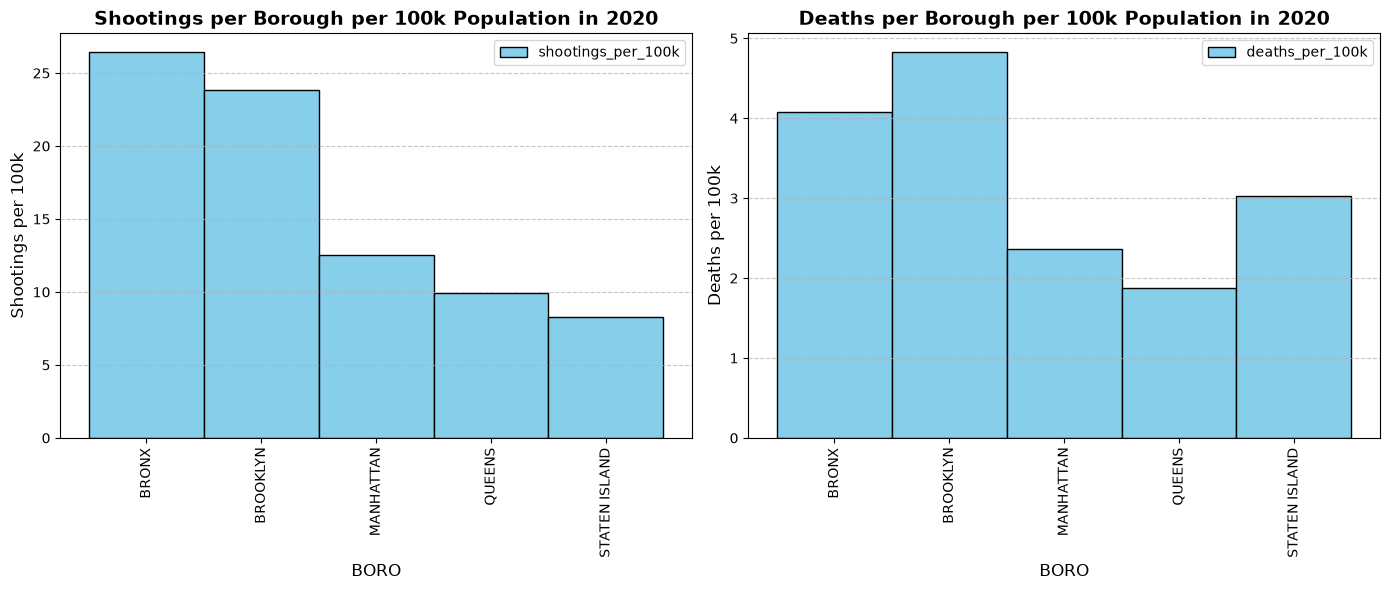

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(14,6))

population_df_2020.plot(x='BORO', y='shootings_per_100k', kind='bar', ax=axs[0], width=1.0, color='skyblue', edgecolor='black')
axs[0].set_title('Shootings per Borough per 100k Population in 2020', fontsize=14, fontweight='bold')
axs[0].set_xlabel('BORO', fontsize=12)
axs[0].set_ylabel('Shootings per 100k', fontsize=12)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

population_df_2020.plot(x='BORO', y='deaths_per_100k', kind='bar', ax=axs[1], width=1.0, color='skyblue', edgecolor='black')
axs[1].set_title('Deaths per Borough per 100k Population in 2020', fontsize=14, fontweight='bold')
axs[1].set_xlabel('BORO', fontsize=12)
axs[1].set_ylabel('Deaths per 100k', fontsize=12)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

- Limitations - those who were wealthier (especially in Manhattan) may have left the city during the Pandemic which would mean shooting and death rate may be lower in some boroughs than in others due to an assumed higher population during the year 2020. 

## Ratio of Inside/Outside City-Wide Per Year (2017–2025)

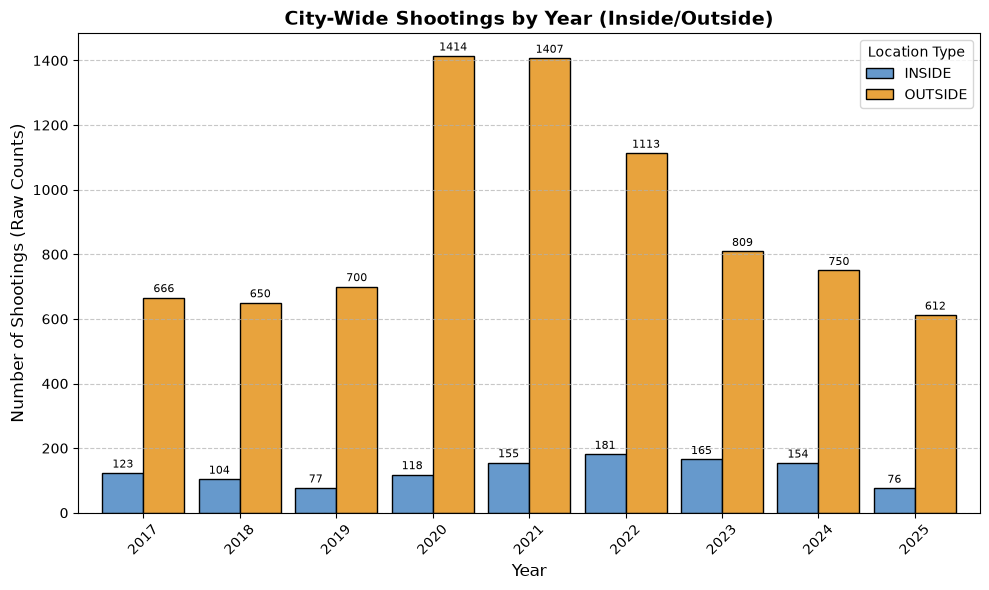

In [26]:
mask = df_shootings['datetime'].between('2017-01-01 00:00:00', '2025-12-31 23:59:59') 
df_masked = df_shootings[mask].copy()
df_masked['year'] = df_masked['datetime'].dt.to_period('Y')
grouped = df_masked.groupby(['year','LOC_OF_OCCUR_DESC']).agg(
    Shootings=('INCIDENT_KEY', 'size'),
    Victims=('n_victims', 'sum'),
    Deaths=('n_deaths', 'sum')
).reset_index()
pivot_df = grouped.pivot_table(
    index='year', 
    columns='LOC_OF_OCCUR_DESC', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#6699CC', '#E8A33D'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('City-Wide Shootings by Year (Inside/Outside)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

## Inside/Outside Shootings Per Borough Per Year (2017–2025)

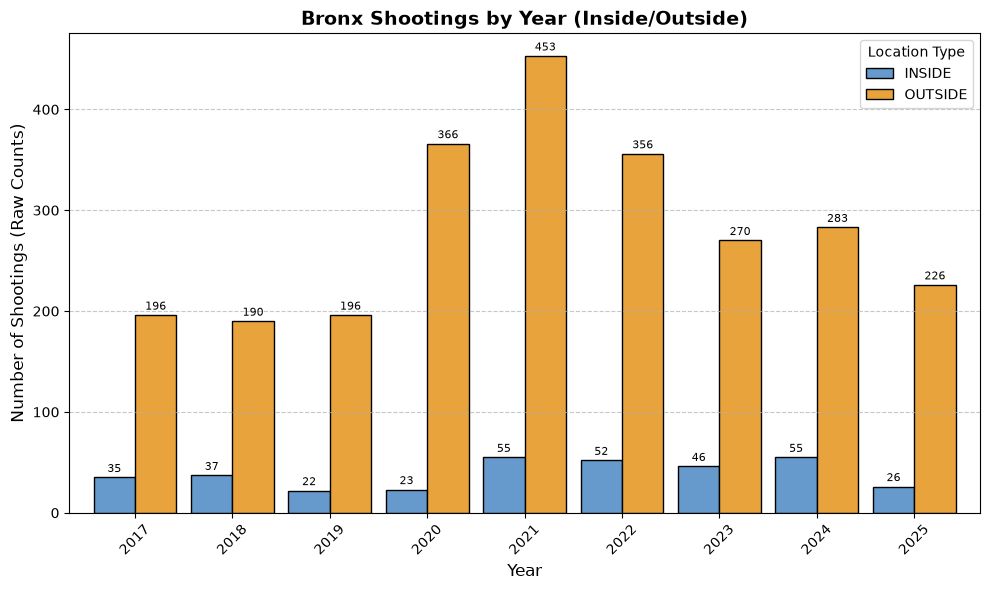

In [27]:
mask = df_shootings['datetime'].between('2017-01-01 00:00:00', '2025-12-31 23:59:59')
df_masked = df_shootings[mask].copy()
df_masked['year'] = df_masked['datetime'].dt.to_period('Y')
grouped = df_masked.groupby(['BORO', 'year','LOC_OF_OCCUR_DESC']).agg(
    Shootings=('INCIDENT_KEY', 'size'),
    Victims=('n_victims', 'sum'),
    Deaths=('n_deaths', 'sum')
).reset_index()

bronx_df = grouped[grouped['BORO']=='BRONX']

pivot_df = bronx_df.pivot_table(
    index='year', 
    columns='LOC_OF_OCCUR_DESC', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#6699CC', '#E8A33D'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Bronx Shootings by Year (Inside/Outside)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

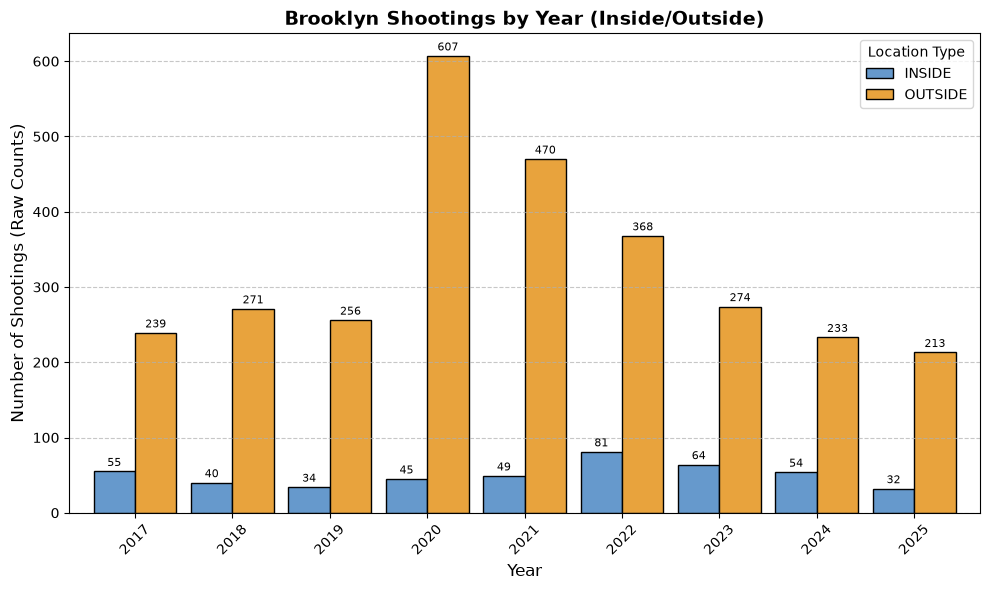

In [28]:

brooklyn_df = grouped[grouped['BORO']=='BROOKLYN']

pivot_df = brooklyn_df.pivot_table(
    index='year', 
    columns='LOC_OF_OCCUR_DESC', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#6699CC', '#E8A33D'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Brooklyn Shootings by Year (Inside/Outside)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

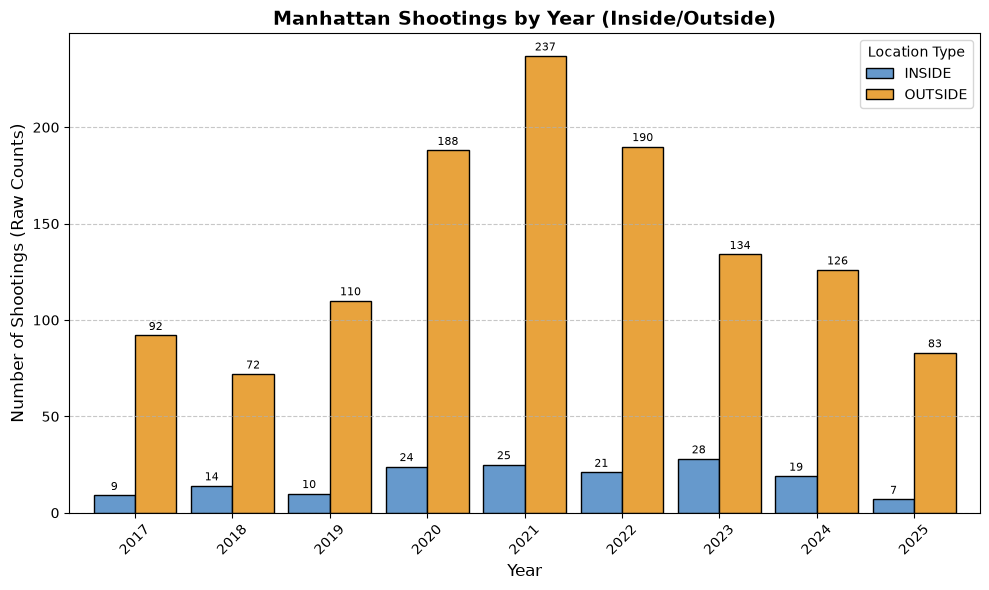

In [29]:
manhattan_df = grouped[grouped['BORO']=='MANHATTAN']

pivot_df = manhattan_df.pivot_table(
    index='year', 
    columns='LOC_OF_OCCUR_DESC', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#6699CC', '#E8A33D'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Manhattan Shootings by Year (Inside/Outside)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

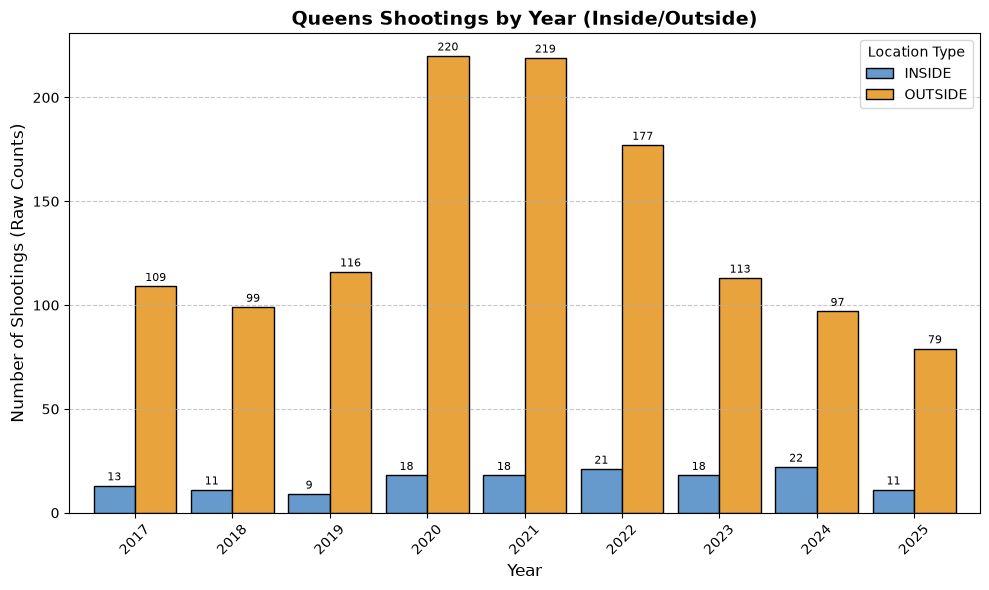

In [30]:
queens_df = grouped[grouped['BORO']=='QUEENS']

pivot_df = queens_df.pivot_table(
    index='year', 
    columns='LOC_OF_OCCUR_DESC', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#6699CC', '#E8A33D'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Queens Shootings by Year (Inside/Outside)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

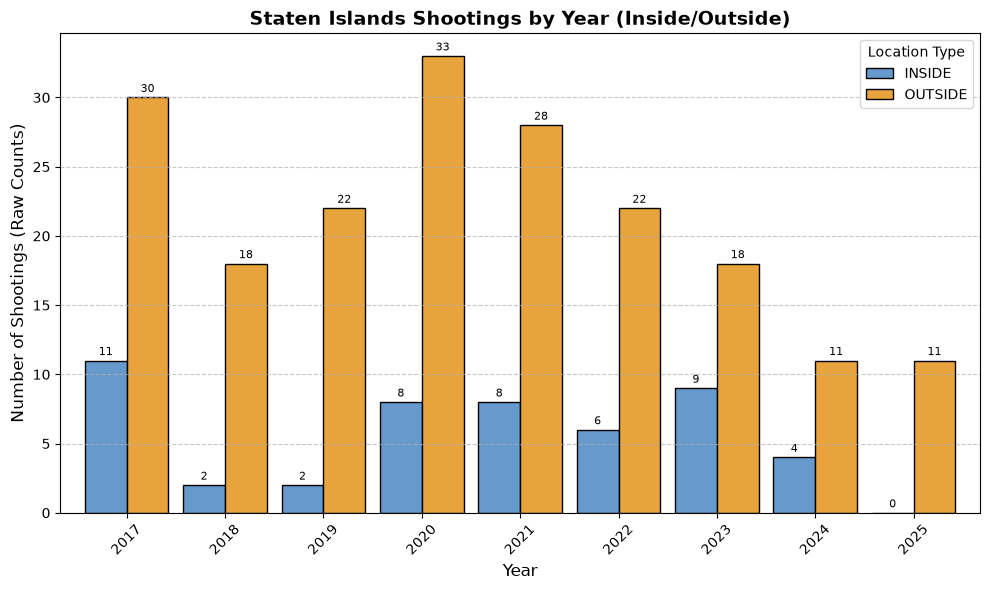

In [31]:
staten_islands_df = grouped[grouped['BORO']=='STATEN ISLAND']

pivot_df = staten_islands_df.pivot_table(
    index='year', 
    columns='LOC_OF_OCCUR_DESC', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#6699CC', '#E8A33D'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Staten Islands Shootings by Year (Inside/Outside)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

## Ratio of Day/Night Shootings City-Wide Per Year (2017–2025)

- Used the astral3.2 https://pypi.org/project/astral/
- Day means it's light enough to see without artificial light. Night means artificial light is required to see. See: 1_DataCleaning.ipynb

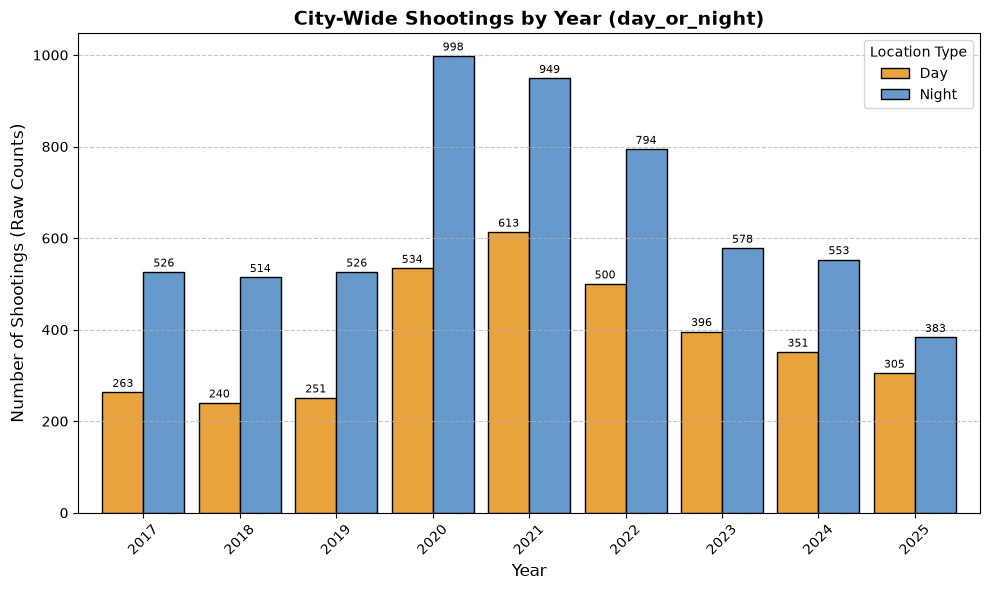

In [32]:
mask = df_shootings['datetime'].between('2017-01-01 00:00:00', '2025-12-31 23:59:59')  
df_masked = df_shootings[mask].copy()
df_masked['year'] = df_masked['datetime'].dt.to_period('Y')
grouped = df_masked.groupby(['year','day_or_night']).agg(
    Shootings=('INCIDENT_KEY', 'size'),
    Victims=('n_victims', 'sum'),
    Deaths=('n_deaths', 'sum')
).reset_index()

pivot_df = grouped.pivot_table(
    index='year', 
    columns='day_or_night', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#E8A33D', '#6699CC'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('City-Wide Shootings by Year (day_or_night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

- In 2025, overall shooting counts are lower than the three years leading up to the pandemic (2017-2019). However, day shootings (city-wide) are still higher during the day. What lowered the total was the reduction of night shootings.

## Day/Night Shootings Per Borough Per Year (2017–2025)

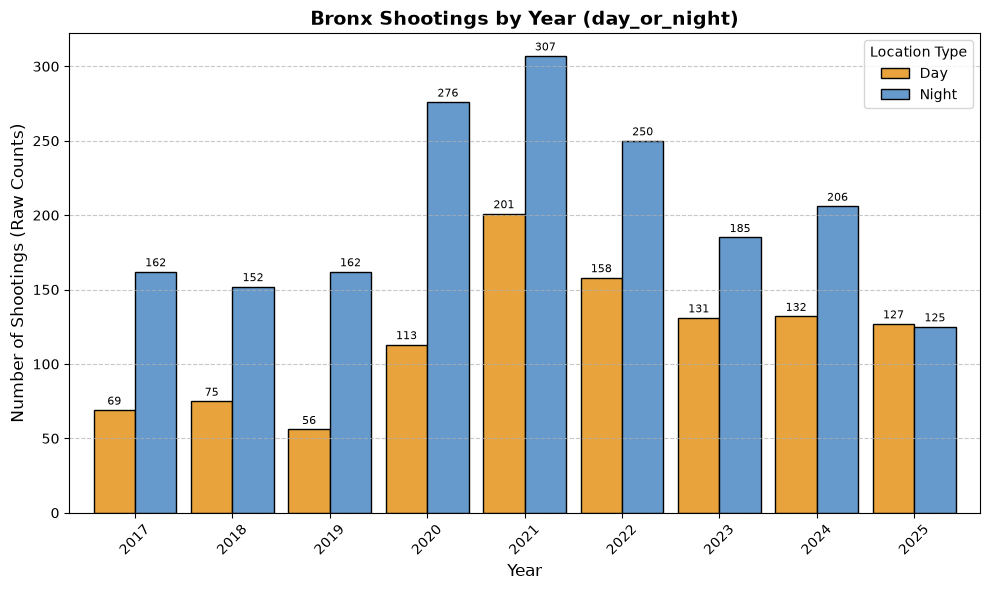

In [33]:
#Now looking at Day/Night ratio of shootings
mask = df_shootings['datetime'].between('2017-01-01 00:00:00', '2025-12-31 23:59:59')
df_masked = df_shootings[mask].copy()
df_masked['year'] = df_masked['datetime'].dt.to_period('Y')
grouped = df_masked.groupby(['BORO', 'year','day_or_night']).agg(
    Shootings=('INCIDENT_KEY', 'size'),
    Victims=('n_victims', 'sum'),
    Deaths=('n_deaths', 'sum')
).reset_index()

bronx_df = grouped[grouped['BORO']=='BRONX']

pivot_df = bronx_df.pivot_table(
    index='year', 
    columns='day_or_night', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#E8A33D', '#6699CC'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Bronx Shootings by Year (day_or_night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

- There are more day shootings in the Bronx in 2025 that Night shootings which is a change from previous years!
- Need to investigate whether this is simply very early morning shootings in the summer (i.e. at dawn or just before dusk and it's just a coincidence)

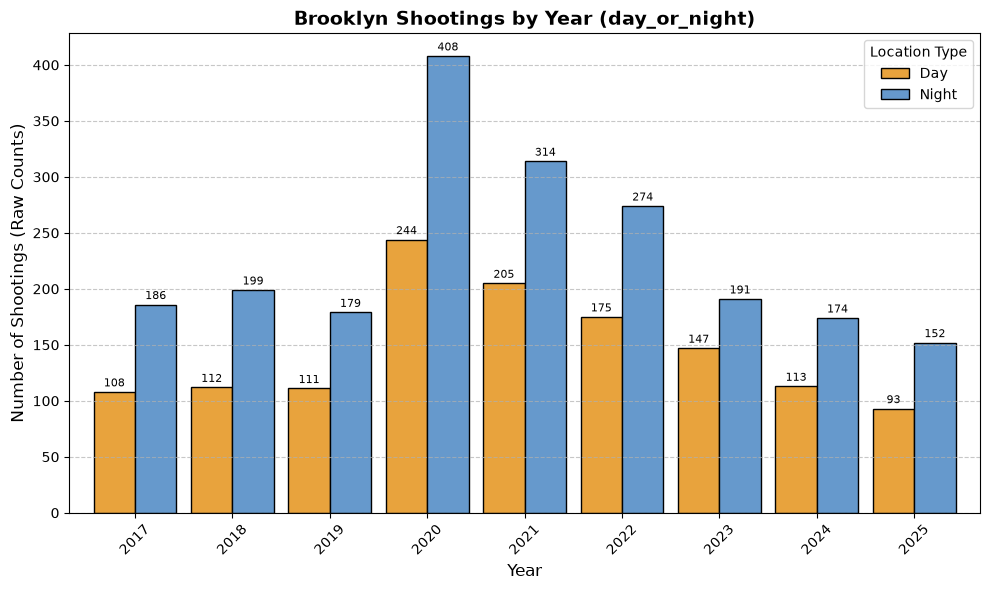

In [34]:
brooklyn_df = grouped[grouped['BORO']=='BROOKLYN']

pivot_df = brooklyn_df.pivot_table(
    index='year', 
    columns='day_or_night', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#E8A33D', '#6699CC'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Brooklyn Shootings by Year (day_or_night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

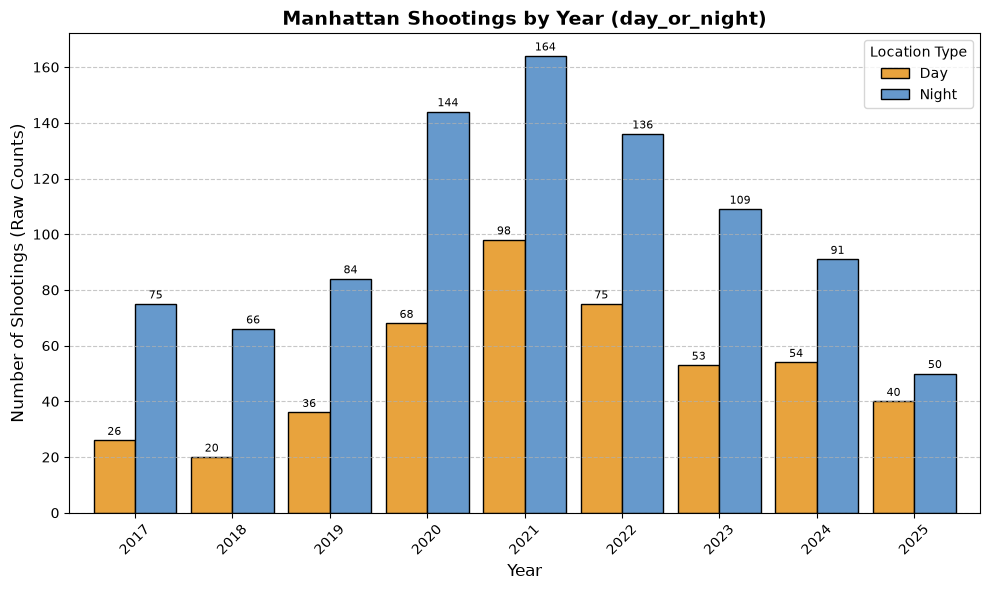

In [35]:
manhattan_df = grouped[grouped['BORO']=='MANHATTAN']

pivot_df = manhattan_df.pivot_table(
    index='year', 
    columns='day_or_night', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#E8A33D', '#6699CC'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Manhattan Shootings by Year (day_or_night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

- Manhattan is also showing far higher proportion of day shootings compared to night shootings in 2025 - again, need to explore this further

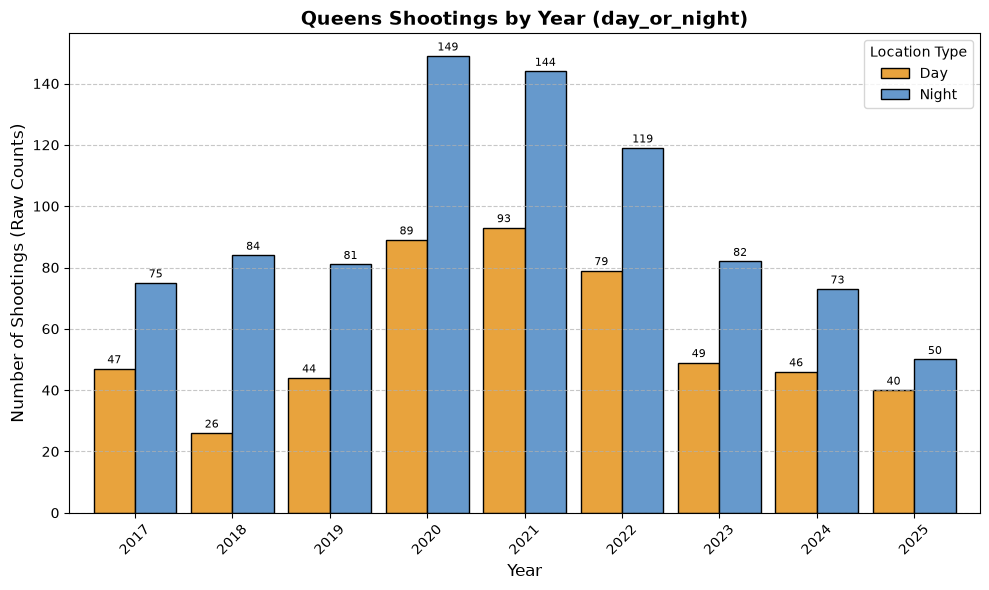

In [36]:
queens_df = grouped[grouped['BORO']=='QUEENS']

pivot_df = queens_df.pivot_table(
    index='year', 
    columns='day_or_night', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#E8A33D', '#6699CC'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Queens Shootings by Year (day_or_night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

- Much like Manhattan (partially) and Bronx, Queens shows much greater drop in night shootings in 2025 than day shootings compared to the previous two years.

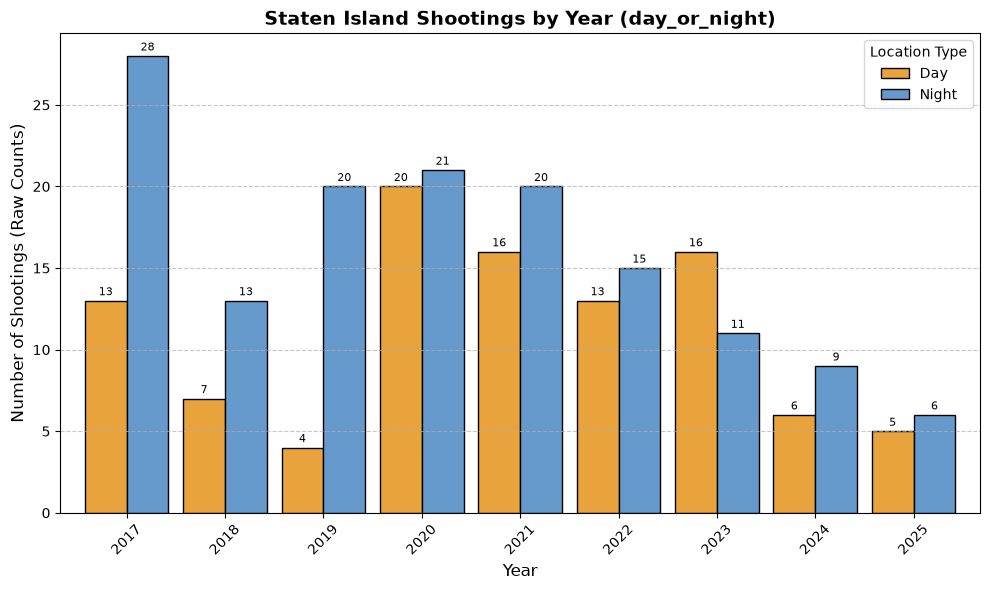

In [37]:
staten_df = grouped[grouped['BORO']=='STATEN ISLAND']

pivot_df = staten_df.pivot_table(
    index='year', 
    columns='day_or_night', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)

pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=False, ax=ax, width=0.85, edgecolor='black', color=['#E8A33D', '#6699CC'])

ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.set_title('Staten Island Shootings by Year (day_or_night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

- Due to the low number of shooting in Staten Island, we expect to see more randomness in whether shootings occured during day or night

# Closer Look at More Precise Shooting Location Information

## Shootings and Deaths by Precinct (2017-2025)

In [38]:
#Some missing values in LOC_CLASSFCTN_DESC so need to be replaced with UNKNOWN
df_shootings['LOC_CLASSFCTN_DESC'] = df_shootings['LOC_CLASSFCTN_DESC'].fillna('UNKNOWN')
#mask out required dates
mask = df_shootings['datetime'].between('2017-01-01 00:00:00', '2025-12-31 23:59:59')
df_masked = df_shootings[mask].copy()
df_masked['year'] = df_masked['datetime'].dt.to_period('Y')

In [39]:
#Precinct
grouped_pcnt = df_masked.groupby(['year', 'PRECINCT', 'BORO'], dropna=False).agg(
    Shootings=('INCIDENT_KEY', 'size'),
    Victims=('n_victims', 'sum'),
    Deaths=('n_deaths', 'sum')
).reset_index()

In [40]:
#Top highest shooting count per Precinct per Borough in 2018
df_2018 = grouped_pcnt[grouped_pcnt['year'] == '2018']
df_sort = df_2018.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2018,44,BRONX,38,49,9
1,2018,40,BRONX,34,36,3
2,2018,42,BRONX,24,28,6
3,2018,73,BROOKLYN,47,60,8
4,2018,67,BROOKLYN,39,42,4
5,2018,75,BROOKLYN,32,36,7
6,2018,23,MANHATTAN,13,16,4
7,2018,32,MANHATTAN,13,15,3
8,2018,34,MANHATTAN,12,13,1
9,2018,114,QUEENS,21,29,6


In [41]:
#Top highest shooting count per Precinct per Borough in 2019
df_2019 = grouped_pcnt[grouped_pcnt['year'] == '2019']
df_sort = df_2019.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2019,42,BRONX,31,32,8
1,2019,44,BRONX,29,32,4
2,2019,46,BRONX,27,32,6
3,2019,75,BROOKLYN,51,63,8
4,2019,73,BROOKLYN,34,54,4
5,2019,79,BROOKLYN,30,34,6
6,2019,23,MANHATTAN,23,30,2
7,2019,32,MANHATTAN,18,20,8
8,2019,25,MANHATTAN,16,17,3
9,2019,113,QUEENS,27,34,5


In [42]:
#Top highest shooting count per Precinct per Borough in 2020
df_2020 = grouped_pcnt[grouped_pcnt['year'] == '2020']
df_sort = df_2020.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2020,40,BRONX,55,68,6
1,2020,44,BRONX,49,63,11
2,2020,47,BRONX,46,51,5
3,2020,75,BROOKLYN,102,124,20
4,2020,73,BROOKLYN,96,116,22
5,2020,79,BROOKLYN,61,81,9
6,2020,23,MANHATTAN,37,45,7
7,2020,32,MANHATTAN,37,47,6
8,2020,25,MANHATTAN,20,20,6
9,2020,103,QUEENS,41,49,5


In [43]:
#Top highest shooting count per Precinct per Borough in 2021
df_2021 = grouped_pcnt[grouped_pcnt['year'] == '2021']
df_sort = df_2021.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2021,44,BRONX,70,88,15
1,2021,42,BRONX,65,75,17
2,2021,40,BRONX,63,71,12
3,2021,73,BROOKLYN,79,92,16
4,2021,75,BROOKLYN,71,85,18
5,2021,67,BROOKLYN,55,61,8
6,2021,32,MANHATTAN,51,62,12
7,2021,34,MANHATTAN,37,48,6
8,2021,23,MANHATTAN,34,36,5
9,2021,113,QUEENS,44,57,10


In [44]:
#Top highest shooting count per Precinct per Borough in 2022
df_2022 = grouped_pcnt[grouped_pcnt['year'] == '2022']
df_sort = df_2022.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2022,44,BRONX,55,62,13
1,2022,40,BRONX,52,66,9
2,2022,48,BRONX,48,60,11
3,2022,75,BROOKLYN,79,90,19
4,2022,73,BROOKLYN,63,79,12
5,2022,67,BROOKLYN,41,48,12
6,2022,32,MANHATTAN,32,38,4
7,2022,25,MANHATTAN,31,43,7
8,2022,34,MANHATTAN,24,24,5
9,2022,103,QUEENS,28,33,6


In [45]:
#Top highest shooting count per Precinct per Borough in 2023
df_2023 = grouped_pcnt[grouped_pcnt['year'] == '2023']
df_sort = df_2023.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2023,44,BRONX,44,54,5
1,2023,46,BRONX,44,56,10
2,2023,47,BRONX,36,41,9
3,2023,75,BROOKLYN,55,66,18
4,2023,73,BROOKLYN,44,48,6
5,2023,67,BROOKLYN,35,42,13
6,2023,25,MANHATTAN,28,30,6
7,2023,32,MANHATTAN,26,29,9
8,2023,34,MANHATTAN,16,21,2
9,2023,114,QUEENS,25,27,5


In [46]:
#Top highest shooting count per Precinct per Borough in 2024
df_2024 = grouped_pcnt[grouped_pcnt['year'] == '2024']
df_sort = df_2024.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2024,46,BRONX,50,65,16
1,2024,40,BRONX,48,54,5
2,2024,44,BRONX,45,61,9
3,2024,75,BROOKLYN,51,53,6
4,2024,73,BROOKLYN,50,62,12
5,2024,67,BROOKLYN,28,32,7
6,2024,32,MANHATTAN,21,24,3
7,2024,34,MANHATTAN,18,21,4
8,2024,23,MANHATTAN,15,18,2
9,2024,103,QUEENS,20,25,1


In [47]:
#Top highest shooting count per Precinct per Borough in 2025 
df_2025 = grouped_pcnt[grouped_pcnt['year'] == '2025']
df_sort = df_2025.sort_values(by=['BORO', 'Shootings'], ascending=[True, False])
top_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
top_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2025,43,BRONX,32,37,8
1,2025,47,BRONX,32,43,7
2,2025,42,BRONX,30,33,7
3,2025,75,BROOKLYN,36,49,5
4,2025,73,BROOKLYN,34,40,5
5,2025,67,BROOKLYN,29,37,6
6,2025,32,MANHATTAN,17,21,2
7,2025,23,MANHATTAN,12,13,2
8,2025,28,MANHATTAN,9,11,3
9,2025,101,QUEENS,12,14,2


In [48]:
#Lowest shooting count per Precinct per Borough in 2025 
df_2025_low = grouped_pcnt[grouped_pcnt['year'] == '2025']
df_sort = df_2025_low.sort_values(by=['BORO', 'Shootings'], ascending=[True, True])
bott_per_boro = df_sort.groupby('BORO').head(3).reset_index(drop=True)
bott_per_boro

,year,PRECINCT,BORO,Shootings,Victims,Deaths
0,2025,50,BRONX,7,10,1
1,2025,49,BRONX,8,14,4
2,2025,45,BRONX,11,15,6
3,2025,62,BROOKLYN,2,2,0
4,2025,76,BROOKLYN,3,4,0
5,2025,72,BROOKLYN,4,4,2
6,2025,5,MANHATTAN,1,1,1
7,2025,13,MANHATTAN,1,1,0
8,2025,20,MANHATTAN,1,1,0
9,2025,105,QUEENS,1,1,1


In [48]:

#Looking at city-wide breakdown of LOC_CLASSFCTN_DESC
grouped = df_masked.groupby(['year','LOC_CLASSFCTN_DESC']).agg(
    Shootings=('INCIDENT_KEY', 'size'),
    Victims=('n_victims', 'sum'),
    Deaths=('n_deaths', 'sum')
).reset_index()

pivot_df = grouped.pivot_table(
    index='year', 
    columns='LOC_CLASSFCTN_DESC', 
    values='Shootings', 
    aggfunc='sum'
).fillna(0)
pivot_df

LOC_CLASSFCTN_DESC,COMMERCIAL,DWELLING,HOUSING,OTHER,PARKING LOT,PLAYGROUND,STREET,TAXI/LIVERY,TRANSIT,UNKNOWN,VEHICLE
year,,,,,,,,,,,
2017,37.0,55.0,156.0,1.0,0.0,17.0,514.0,1.0,0.0,0.0,8.0
2018,24.0,48.0,144.0,3.0,5.0,11.0,505.0,0.0,2.0,2.0,10.0
2019,15.0,36.0,155.0,6.0,3.0,10.0,535.0,0.0,6.0,2.0,9.0
2020,35.0,53.0,319.0,7.0,1.0,11.0,1077.0,2.0,4.0,1.0,22.0
2021,37.0,70.0,266.0,8.0,1.0,15.0,1142.0,1.0,5.0,1.0,16.0
2022,64.0,104.0,225.0,23.0,4.0,18.0,829.0,0.0,9.0,0.0,18.0
2023,78.0,87.0,161.0,22.0,8.0,10.0,594.0,0.0,6.0,2.0,6.0
2024,53.0,80.0,157.0,13.0,1.0,15.0,570.0,0.0,8.0,5.0,2.0
2025,23.0,51.0,139.0,6.0,0.0,7.0,456.0,0.0,3.0,3.0,0.0


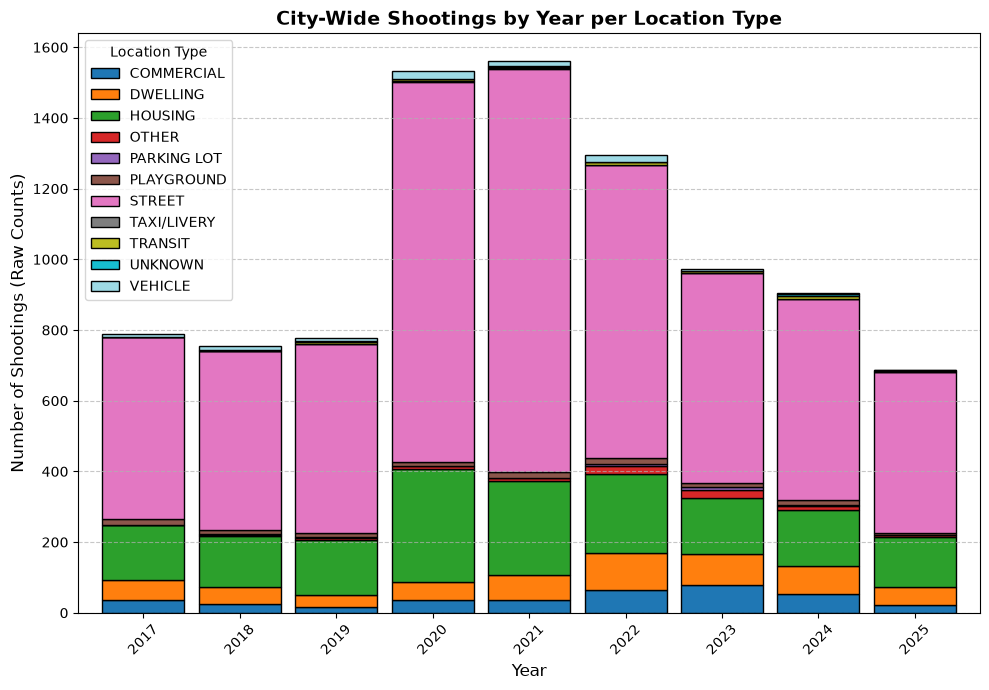

In [49]:
pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 7))
pastel_colors = ['#FFB7B2', '#FFDAC1', '#E2F0CB', '#B5EAD7', '#C7CEEA']
pivot_df.plot(kind='bar', stacked=True, ax=ax, width=0.85, edgecolor='black', colormap='tab20')

ax.set_title('City-Wide Shootings by Year per Location Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Shootings (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

In [50]:
#Looking at deaths
pivot_df = grouped.pivot_table(
    index='year', 
    columns='LOC_CLASSFCTN_DESC', 
    values='Deaths', 
    aggfunc='sum'
).fillna(0)
pivot_df

LOC_CLASSFCTN_DESC,COMMERCIAL,DWELLING,HOUSING,OTHER,PARKING LOT,PLAYGROUND,STREET,TAXI/LIVERY,TRANSIT,UNKNOWN,VEHICLE
year,,,,,,,,,,,
2017,14.0,13.0,27.0,1.0,0.0,1.0,82.0,0.0,0.0,0.0,8.0
2018,8.0,30.0,30.0,0.0,2.0,5.0,75.0,0.0,0.0,0.0,10.0
2019,10.0,21.0,32.0,1.0,0.0,2.0,76.0,0.0,2.0,0.0,10.0
2020,16.0,21.0,57.0,0.0,0.0,6.0,168.0,1.0,0.0,0.0,23.0
2021,11.0,36.0,62.0,1.0,0.0,4.0,194.0,1.0,0.0,0.0,16.0
2022,20.0,33.0,37.0,2.0,1.0,8.0,136.0,0.0,3.0,0.0,14.0
2023,21.0,39.0,25.0,2.0,1.0,2.0,116.0,0.0,1.0,0.0,0.0
2024,5.0,30.0,25.0,0.0,0.0,2.0,110.0,0.0,4.0,2.0,2.0
2025,11.0,14.0,20.0,0.0,0.0,3.0,96.0,0.0,0.0,2.0,0.0


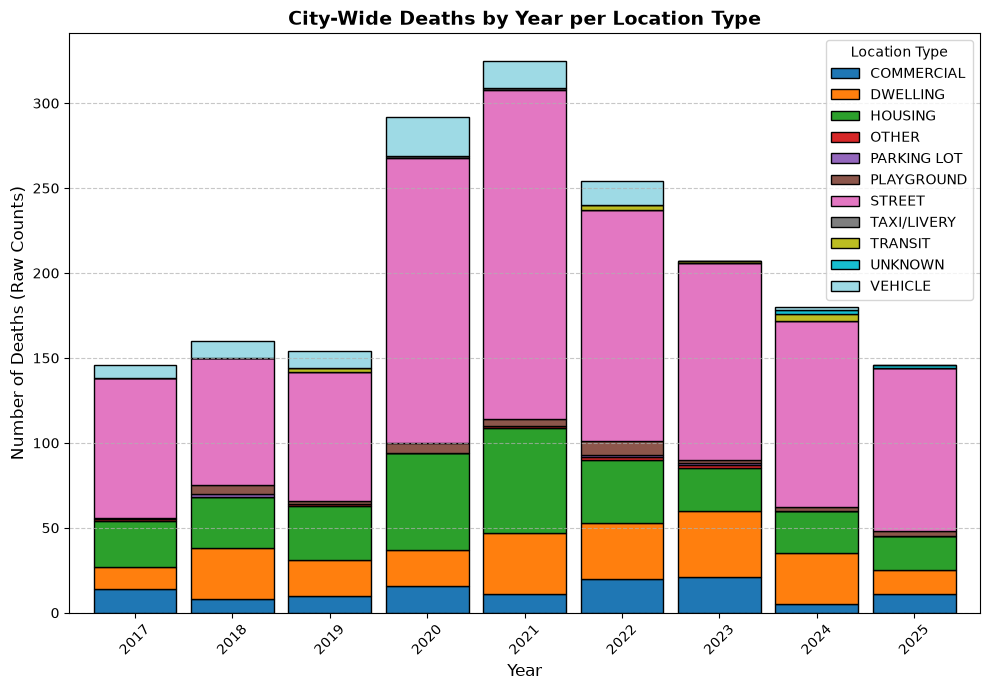

In [51]:
pivot_df.index = pivot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 7))
pastel_colors = ['#FFB7B2', '#FFDAC1', '#E2F0CB', '#B5EAD7', '#C7CEEA']
pivot_df.plot(kind='bar', stacked=True, ax=ax, width=0.85, edgecolor='black', colormap='tab20')

ax.set_title('City-Wide Deaths by Year per Location Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Deaths (Raw Counts)', fontsize=12)
ax.legend(title='Location Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

## Shootings by Hour of Day in 2025 City-Wide

- Counting shootings city-wide because a by borough breakdown is too fine grained 

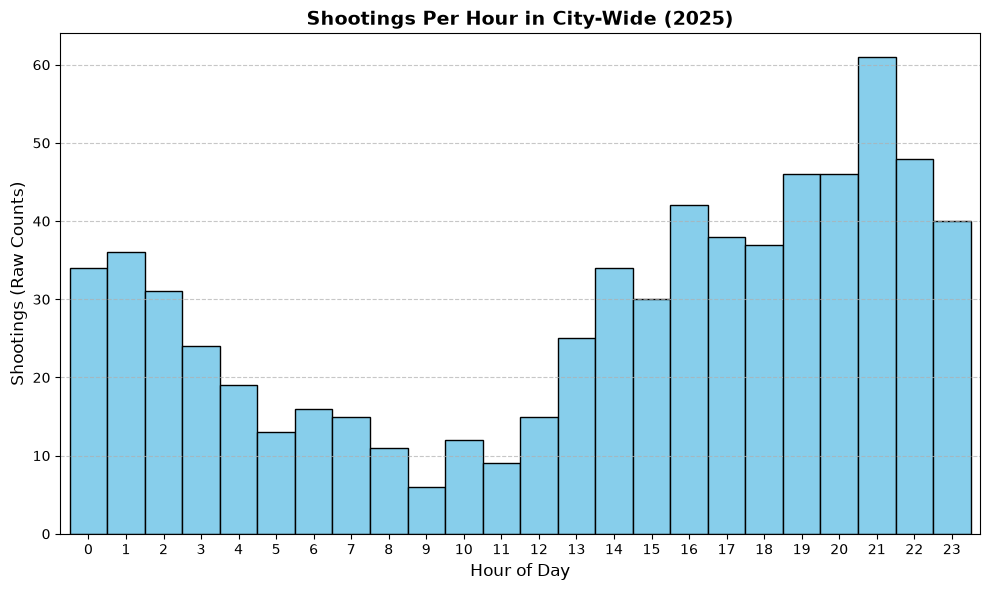

In [43]:
mask = df_shootings['datetime'].between('2025-01-01 00:00:00', '2025-12-31 23:59:59') 
df_masked_2025_city = df_shootings[mask].copy()

shootings_per_Hour_2025_City = df_masked_2025_city['datetime'].dt.hour.value_counts(normalize=False).sort_index()
plt.figure(figsize=(10,6))
shootings_per_Hour_2025_City.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Hour in City-Wide (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Shootings (Raw Counts)', fontsize=12)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

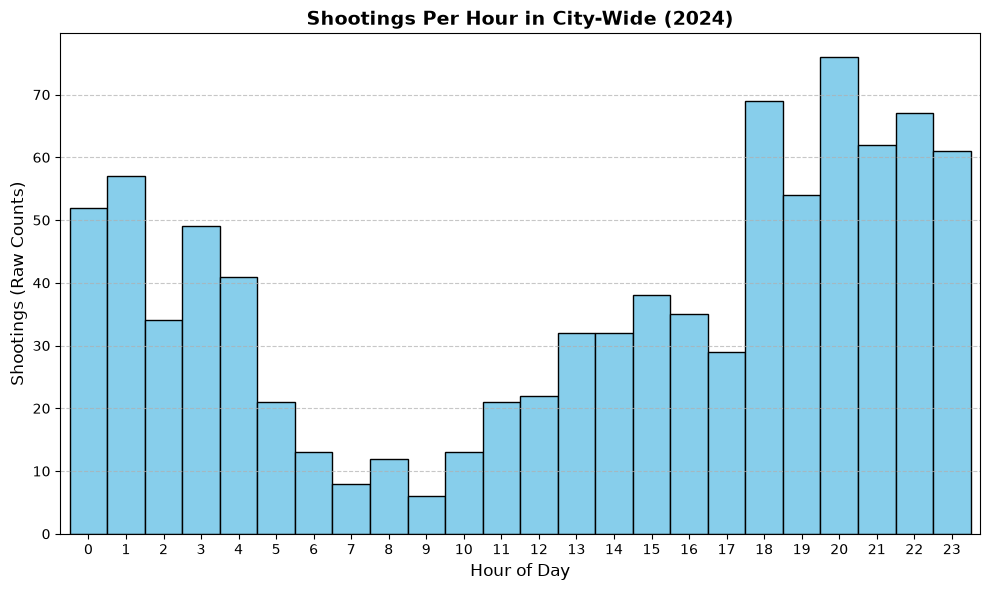

In [44]:
mask = df_shootings['datetime'].between('2024-01-01 00:00:00', '2024-12-31 23:59:59') 
df_masked_2024_city = df_shootings[mask].copy()

shootings_per_Hour_2024_City = df_masked_2024_city['datetime'].dt.hour.value_counts(normalize=False).sort_index()
plt.figure(figsize=(10,6))
shootings_per_Hour_2024_City.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Hour in City-Wide (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Shootings (Raw Counts)', fontsize=12)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

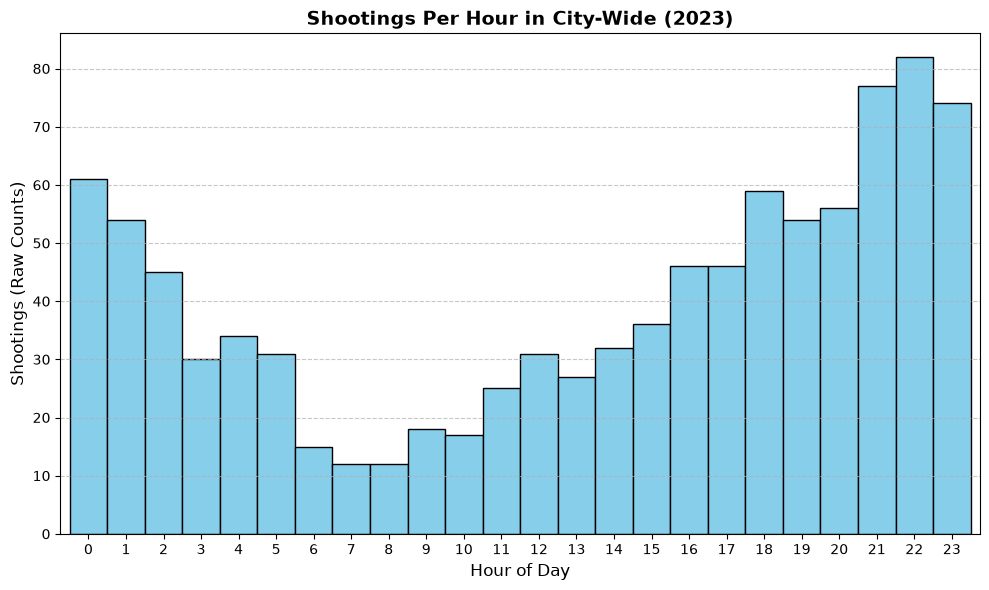

In [45]:
mask = df_shootings['datetime'].between('2023-01-01 00:00:00', '2023-12-31 23:59:59') 
df_masked_2023_city = df_shootings[mask].copy()

shootings_per_Hour_2023_City = df_masked_2023_city['datetime'].dt.hour.value_counts(normalize=False).sort_index()
plt.figure(figsize=(10,6))
shootings_per_Hour_2023_City.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Hour in City-Wide (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Shootings (Raw Counts)', fontsize=12)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

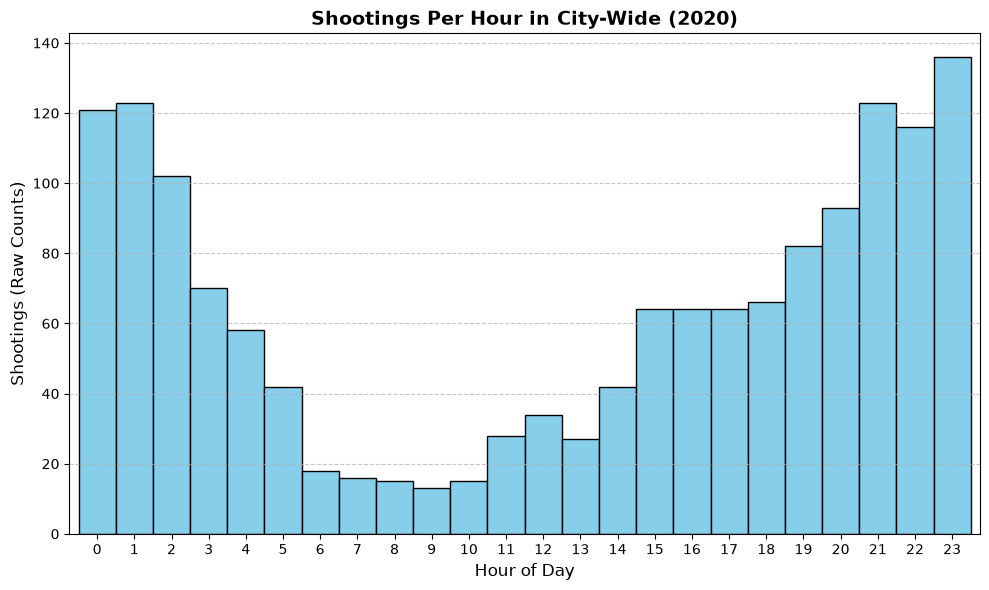

In [46]:
mask = df_shootings['datetime'].between('2020-01-01 00:00:00', '2020-12-31 23:59:59')
df_masked_2020_city = df_shootings[mask].copy()

shootings_per_Hour_2020_City = df_masked_2020_city['datetime'].dt.hour.value_counts(normalize=False).sort_index()
plt.figure(figsize=(10,6))
shootings_per_Hour_2020_City.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Hour in City-Wide (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Shootings (Raw Counts)', fontsize=12)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

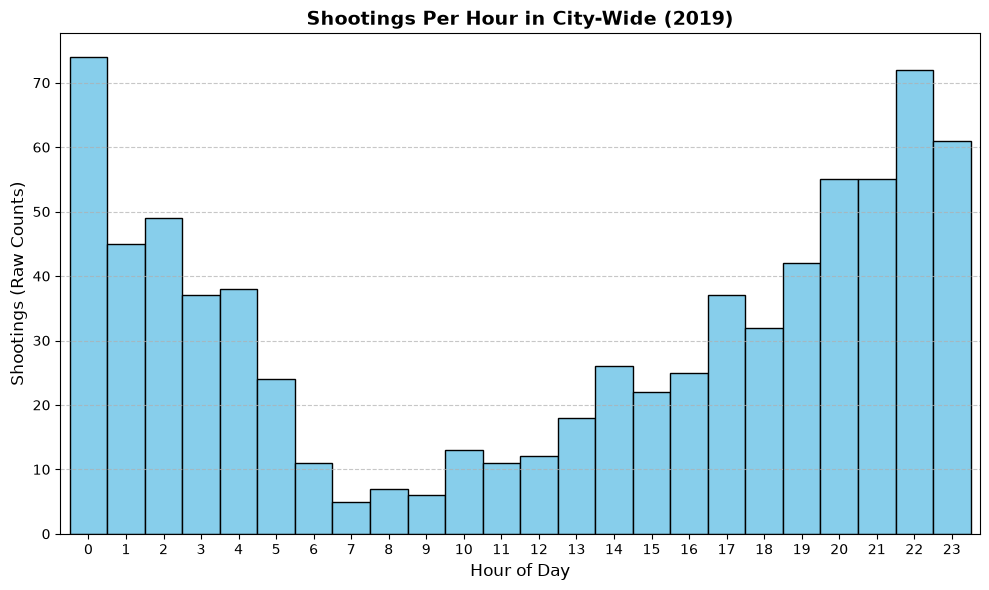

In [47]:
mask = df_shootings['datetime'].between('2019-01-01 00:00:00', '2019-12-31 23:59:59') 
df_masked_2019_city = df_shootings[mask].copy()

shootings_per_Hour_2019_City = df_masked_2019_city['datetime'].dt.hour.value_counts(normalize=False).sort_index()
plt.figure(figsize=(10,6))
shootings_per_Hour_2019_City.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Hour in City-Wide (2019)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Shootings (Raw Counts)', fontsize=12)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

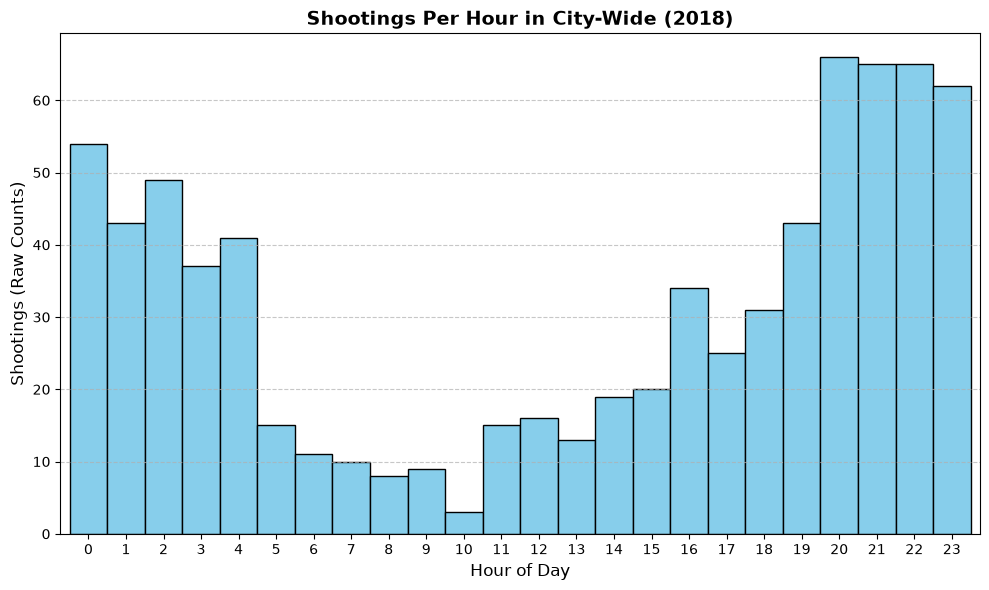

In [48]:
mask = df_shootings['datetime'].between('2018-01-01 00:00:00', '2018-12-31 23:59:59')  
df_masked_2018_city = df_shootings[mask].copy()

shootings_per_Hour_2018_City = df_masked_2018_city['datetime'].dt.hour.value_counts(normalize=False).sort_index()
plt.figure(figsize=(10,6))
shootings_per_Hour_2018_City.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Hour in City-Wide (2018)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Shootings (Raw Counts)', fontsize=12)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

## Which Day of Week Has More Shootings City-Wide?

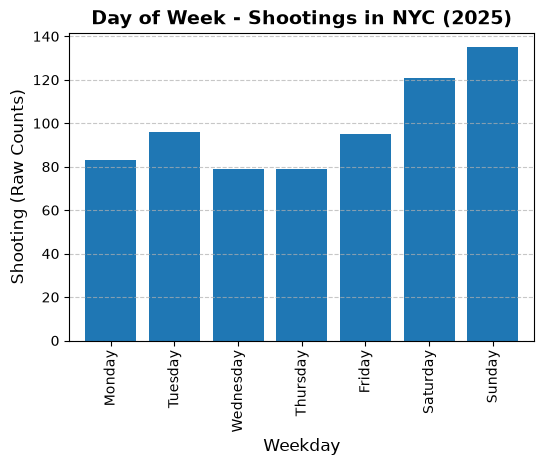

In [49]:
#Which day of week has more shootings city-wide?
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

mask = df_shootings['datetime'].between('2025-01-01 00:00:00', '2025-12-31 23:59:59')  
df_masked_2025_dow_city = df_shootings[mask].copy()

day_of_week_counts = df_masked_2025_dow_city["day_of_week"].value_counts(normalize=False).sort_index()
plt.figure(figsize=(6,4))
day_of_week_counts.reindex(day_order).plot(kind='bar', width=0.8)
plt.title('Day of Week - Shootings in NYC (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Shooting (Raw Counts)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

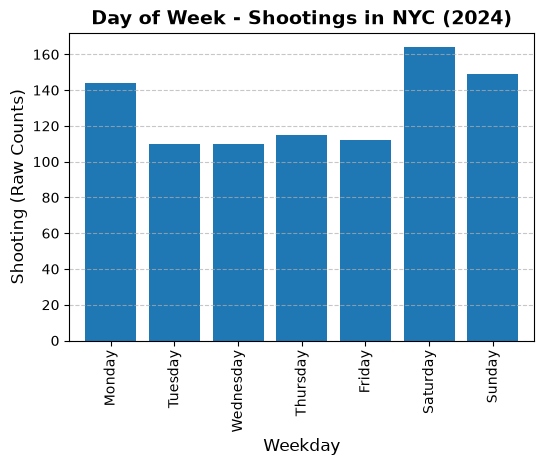

In [50]:
mask = df_shootings['datetime'].between('2024-01-01 00:00:00', '2024-12-31 23:59:59') 
df_masked_2024_dow_city = df_shootings[mask].copy()

day_of_week_counts = df_masked_2024_dow_city["day_of_week"].value_counts(normalize=False).sort_index()
plt.figure(figsize=(6,4))
day_of_week_counts.reindex(day_order).plot(kind='bar', width=0.8)
plt.title('Day of Week - Shootings in NYC (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Shooting (Raw Counts)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

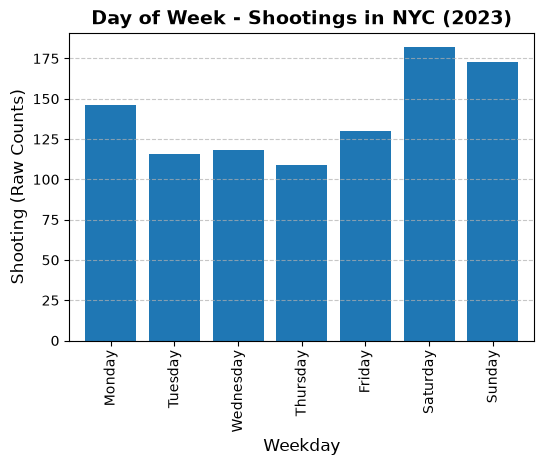

In [51]:
mask = df_shootings['datetime'].between('2023-01-01 00:00:00', '2023-12-31 23:59:59') 
df_masked_2023_dow_city = df_shootings[mask].copy()

day_of_week_counts = df_masked_2023_dow_city["day_of_week"].value_counts(normalize=False).sort_index()
plt.figure(figsize=(6,4))
day_of_week_counts.reindex(day_order).plot(kind='bar', width=0.8)
plt.title('Day of Week - Shootings in NYC (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Shooting (Raw Counts)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

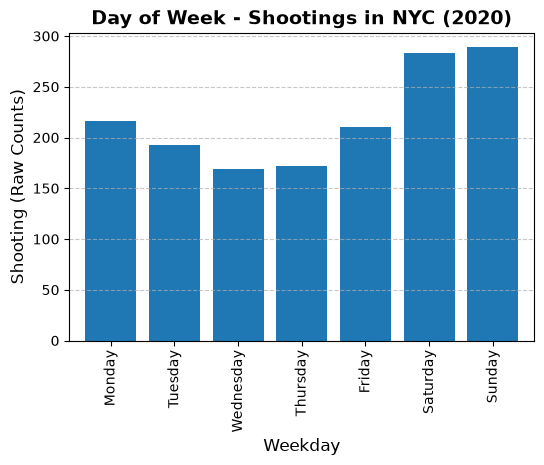

In [52]:
mask = df_shootings['datetime'].between('2020-01-01 00:00:00', '2020-12-31 23:59:59') 
df_masked_2020_dow_city = df_shootings[mask].copy()

day_of_week_counts = df_masked_2020_dow_city["day_of_week"].value_counts(normalize=False).sort_index()
plt.figure(figsize=(6,4))
day_of_week_counts.reindex(day_order).plot(kind='bar', width=0.8)
plt.title('Day of Week - Shootings in NYC (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Shooting (Raw Counts)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

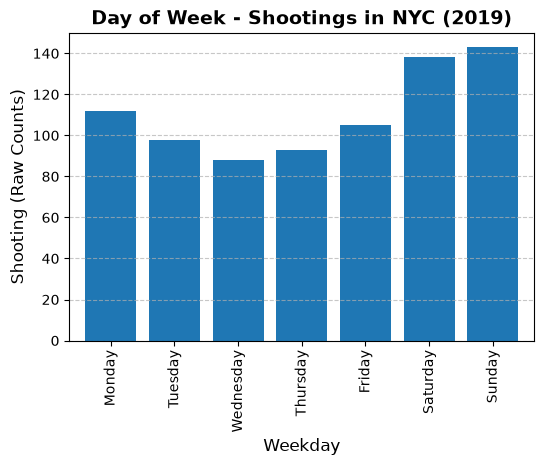

In [53]:
mask = df_shootings['datetime'].between('2019-01-01 00:00:00', '2019-12-31 23:59:59') 
df_masked_2019_dow_city = df_shootings[mask].copy()

day_of_week_counts = df_masked_2019_dow_city["day_of_week"].value_counts(normalize=False).sort_index()
plt.figure(figsize=(6,4))
day_of_week_counts.reindex(day_order).plot(kind='bar', width=0.8)
plt.title('Day of Week - Shootings in NYC (2019)', fontsize=14, fontweight='bold')
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Shooting (Raw Counts)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

## Maps

In [74]:
df_shootings.isna().sum()

INCIDENT_KEY              0
BORO                      0
LOC_OF_OCCUR_DESC         0
PRECINCT                  0
JURISDICTION_CODE         2
LOC_CLASSFCTN_DESC        0
LOCATION_DESC         14434
X_COORD_CD                1
Y_COORD_CD                1
Latitude                  1
Longitude                 1
datetime                  0
day_of_week               0
day_or_night              0
n_victims                 0
n_deaths                  0
dtype: int64

In [75]:
df_shootings_map = df_shootings[['BORO', 'LOC_OF_OCCUR_DESC','LOC_CLASSFCTN_DESC','PRECINCT','X_COORD_CD','Y_COORD_CD', 'Latitude', 'Longitude', 'datetime', 'day_of_week', 'day_or_night', 'n_victims', 'n_deaths']].copy()
df_shootings_map.isna().sum()

BORO                  0
LOC_OF_OCCUR_DESC     0
LOC_CLASSFCTN_DESC    0
PRECINCT              0
X_COORD_CD            1
Y_COORD_CD            1
Latitude              1
Longitude             1
datetime              0
day_of_week           0
day_or_night          0
n_victims             0
n_deaths              0
dtype: int64

In [76]:
#Seeing how many rows have missing values for coordinates
df_shootings_map[
(df_shootings_map["X_COORD_CD"].isna()) |
(df_shootings_map["Y_COORD_CD"].isna())|
(df_shootings_map["Latitude"].isna()) |
(df_shootings_map["Longitude"].isna())
       
 ]

,BORO,LOC_OF_OCCUR_DESC,LOC_CLASSFCTN_DESC,PRECINCT,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths
22113,BROOKLYN,OUTSIDE,STREET,61,NaN,NaN,NaN,NaN,2026-03-24 02:14:00,Tuesday,Night,1,0


In [77]:
df_shootings_map = df_shootings_map.dropna()
df_shootings_map.isna().sum()

BORO                  0
LOC_OF_OCCUR_DESC     0
LOC_CLASSFCTN_DESC    0
PRECINCT              0
X_COORD_CD            0
Y_COORD_CD            0
Latitude              0
Longitude             0
datetime              0
day_of_week           0
day_or_night          0
n_victims             0
n_deaths              0
dtype: int64

In [78]:
#Some data coordinates could be duplicates (i.e. hold more than one shooting event)
#Looking for duplicates in long and lat
df_shootings_map.value_counts(['Latitude', 'Longitude']).head(10)

Latitude   Longitude 
40.671360  -73.881811    40
40.853598  -73.900577    38
40.671130  -73.913502    34
40.837842  -73.919628    32
40.662768  -73.907533    32
40.638984  -74.171256    30
40.667573  -73.907296    30
40.615477  -74.081667    27
40.788457  -73.939376    27
40.679981  -73.776234    25
Name: count, dtype: int64

- Up to **40 separate shooting incidents** can be in one coordinate location over 20 year period. This is because all shooting coordinates are assigned to the nearest intersection or geo-located to the middle of the nearest street segment where appropriate and not the exact location of the shooting. This is to protect identity of victims and local businesses. 

In [79]:
#Let's separate the time and year from datetime and place it into a new column called 'year' and 'nearest_hour' 
#We can colour code the ime component on the map below
df_shootings_map['nearest_hour'] = df_shootings_map['datetime'].dt.round('h').dt.time
df_shootings_map['year'] = df_shootings_map['datetime'].dt.year

In [80]:
df_shootings_map_2023_2025 = df_shootings_map[df_shootings_map['datetime'].between('2023-01-01 00:00:00', '2025-12-31 23:59:59')].sort_values('datetime')
df_shootings_map_2023_2025

,BORO,LOC_OF_OCCUR_DESC,LOC_CLASSFCTN_DESC,PRECINCT,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths,nearest_hour,year
20310,BRONX,OUTSIDE,STREET,47,1023283.0,264964.0,40.893861,-73.858820,2023-01-01 05:55:00,Sunday,Night,1,0,06:00:00,2023
19332,BRONX,OUTSIDE,STREET,40,1005216.0,235339.0,40.812610,-73.924261,2023-01-01 06:47:00,Sunday,Night,1,0,07:00:00,2023
22563,BRONX,OUTSIDE,STREET,52,1012886.0,253829.0,40.863338,-73.896473,2023-01-02 19:38:00,Monday,Night,1,0,20:00:00,2023
19333,BROOKLYN,OUTSIDE,STREET,67,1007548.0,179060.0,40.658133,-73.916031,2023-01-03 01:47:00,Tuesday,Night,1,0,02:00:00,2023
23436,BROOKLYN,INSIDE,COMMERCIAL,72,982383.0,177997.0,40.655245,-74.006730,2023-01-03 03:19:00,Tuesday,Night,1,0,03:00:00,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23994,BRONX,INSIDE,HOUSING,49,1025102.0,256070.0,40.869441,-73.852295,2025-12-27 18:25:00,Saturday,Night,2,1,18:00:00,2025
22533,BROOKLYN,INSIDE,HOUSING,77,1001597.0,185351.0,40.675414,-73.937463,2025-12-30 03:30:00,Tuesday,Night,1,0,04:00:00,2025
21786,QUEENS,OUTSIDE,STREET,101,1054183.0,157004.0,40.597348,-73.748179,2025-12-30 18:41:00,Tuesday,Night,1,1,19:00:00,2025
22861,MANHATTAN,INSIDE,HOUSING,32,1000457.0,238373.0,40.820948,-73.941445,2025-12-31 18:40:00,Wednesday,Night,1,0,19:00:00,2025


In [81]:
df_shootings_map_2023_2025.value_counts(['Latitude', 'Longitude']).head(10)
#shootings probably have multiple shootings in same coordinates as well (see directly below)

Latitude   Longitude 
40.853598  -73.900577    22
40.671360  -73.881811    20
40.671130  -73.913502    16
40.844157  -73.900605    15
40.837842  -73.919628    15
40.822912  -73.870041    12
40.822271  -73.911698    11
40.648851  -73.951017     9
40.815913  -73.945149     9
40.810352  -73.924942     9
Name: count, dtype: int64

- We could introduce a slight jitter effect on these plot points so they aren't hidden beneath one another and because these plot points are not exact GPS coordinates of the shootings

In [82]:
#Using Jitter for plot points so they do not all overlap
df_jittered = df_shootings_map_2023_2025.copy()

lat_jitter = 0.00010     
lon_jitter = 0.00013     #This value is slightly higher to ensure scattering is roughly circular

df_jittered['year'] = df_jittered['year'].astype(str)

np.random.seed(41) # this will ensure I get the same random points each time
df_jittered['Latitude'] += np.random.uniform(-lat_jitter, lat_jitter, size=len(df_jittered))
df_jittered['Longitude'] += np.random.uniform(-lon_jitter, lon_jitter, size=len(df_jittered))

gdf_jittered = gpd.GeoDataFrame(
    df_jittered, 
    geometry=gpd.points_from_xy(df_jittered.Longitude, df_jittered.Latitude), 
    crs="EPSG:4326"
)

m = gdf_jittered.explore(
    column='year',       
    #cmap='twilight_shifted', # For 'nearest_hour' - Cyclic Colormap due to cyclical 24 hour clock
    cmap='viridis',
    #tiles='OpenStreetMap',
    #tiles='CartoDB dark_matter',
    tiles='CartoDB positron',
    marker_kwds=dict(
        radius=4,
        fill=True,
        weight=1,
        opacity=1
    )
)

m.get_root().width = '1200px'
m.get_root().height = '750px'
m


Maps will not provide detailed and accurate shooting locations at the street level (see below).
- "Many other shooting incidents that were not able to be geo-coded (for example, due to an invalid address) have been located as occurring at the police station house within the precinct of occurrence." Examples include: Police Officer Jill Garcia Place, Bronx, NY 10457 and 830 Washington Ave, Bronx, NY 10451, United States which correspond to the 48th and 42nd Precinct Station House respectively. These locations can look like hotspots when they are not.
- https://data.cityofnewyork.us/Public-Safety/ARCHIVED_NYPD-Shooting-Incident-Data-Year-To-Date-/98wc-x49t/about_data contains footnote pdf explaining this: https://data.cityofnewyork.us/api/views/98wc-x49t/files/ec9fa5b4-2cfa-4af0-af44-594b85ace55b?download=true&filename=NYPD_Shootings_Incident_Level_Data_Footnotes.pdf 


___

## Shootings and Deaths (Quarterly Totals)

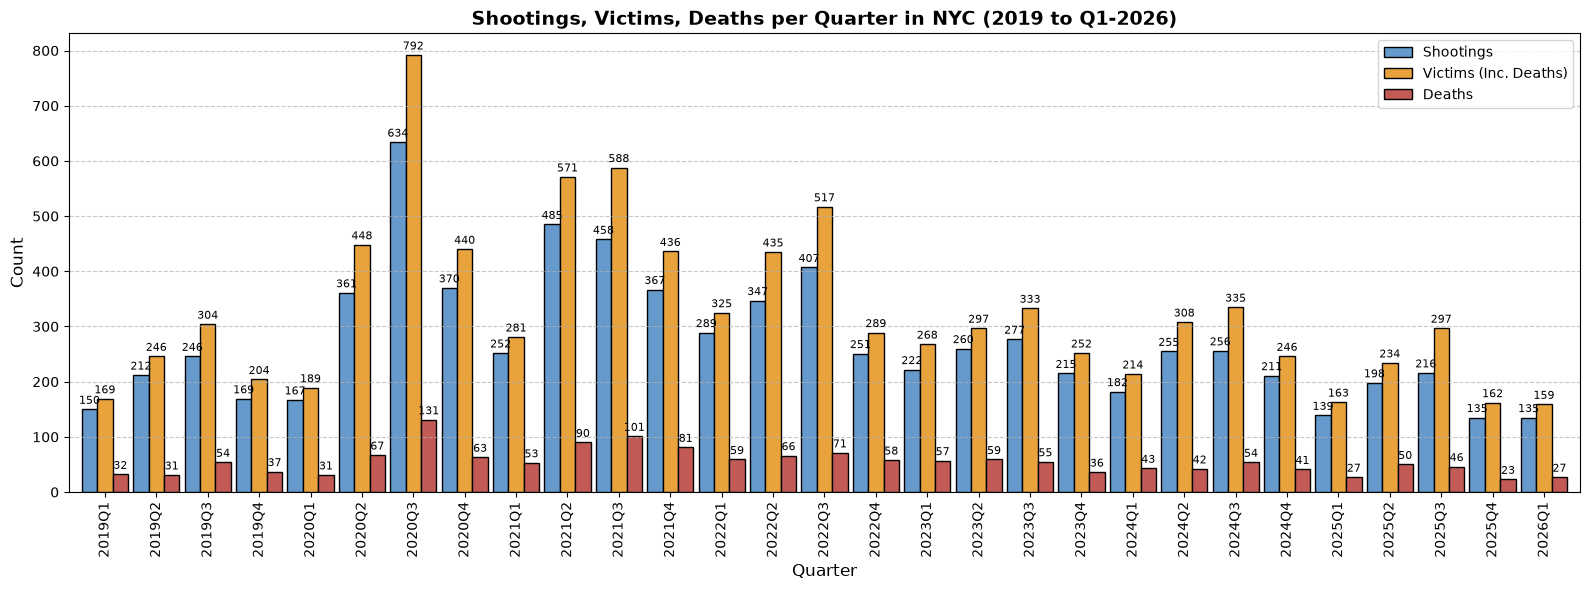

In [21]:
mask = df_shootings['datetime'].between('2019-01-01', '2026-03-31')
df_masked = df_shootings[mask].copy()
quarter = df_masked['datetime'].dt.to_period('Q')

summary = pd.DataFrame({
    'Shootings': df_masked.groupby(quarter).size(),
    'Victims (Inc. Deaths)': df_masked.groupby(quarter)['n_victims'].sum(),
    'Deaths': df_masked.groupby(quarter)['n_deaths'].sum()
}).sort_index()

ax = summary.plot(
    kind='bar',
    figsize=(16,6),
    color=['#6699CC', '#E8A33D', '#C25B56'],
    edgecolor='black',
    width=0.9
)
ax.bar_label(ax.containers[0], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[1], fontsize=8, color='#000', padding=2)
ax.bar_label(ax.containers[2], fontsize=8, color='#000', padding=2)

plt.title("Shootings, Victims, Deaths per Quarter in NYC (2019 to Q1-2026)", fontsize=14, fontweight='bold')
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

- This Incident_key (203259656) is not found in the shootings dataset. So will remove this row from victims dataset **df_victims**.

In [34]:
#Need to drop the single missing row from df_victims before we can merge with df_shootings
df_victims = df_victims.dropna()

In [2]:
#Did a shooting result in at least one murder?
'''
df_merged = df_shootings.merge(
    df_victims[["INCIDENT_KEY", "STAT_MURDER_FLG"]], on="INCIDENT_KEY", how="left"
)
df_merged
''';

In [36]:
#check for missing values in STAT_MURDER_FLG in df_merged
df_merged[df_merged['STAT_MURDER_FLG'].isna()]

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,STAT_MURDER_FLG


In [40]:
# Number of rows of missing values in df_merged
df_merged.isna().sum()

INCIDENT_KEY           0
BORO                   0
LOC_OF_OCCUR_DESC      0
PRECINCT               0
JURISDICTION_CODE      2
LOC_CLASSFCTN_DESC    35
X_COORD_CD             1
Y_COORD_CD             1
Latitude               1
Longitude              1
datetime               0
day_of_week            0
day_or_night           0
STAT_MURDER_FLG        0
dtype: int64

- Academic paper titled: **Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis** may shed light on spike in shootings from Q2 2020 See: https://pmc.ncbi.nlm.nih.gov/articles/PMC9095435/
- Citation: Wolff KT, Intravia J, Baglivio MT, Piquero AR. Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis. J Crim Justice. 2022 Jul-Aug;81:101929. doi: 10.1016/j.jcrimjus.2022.101929. Epub 2022 May 12. PMID: 35578726; PMCID: PMC9095435. 

- New York Times: "In 2020, murders in the United States spiked more than 27 percent — the largest percentage increase in at least six decades." https://www.nytimes.com/2022/01/18/briefing/crime-surge-homicides-us.html 

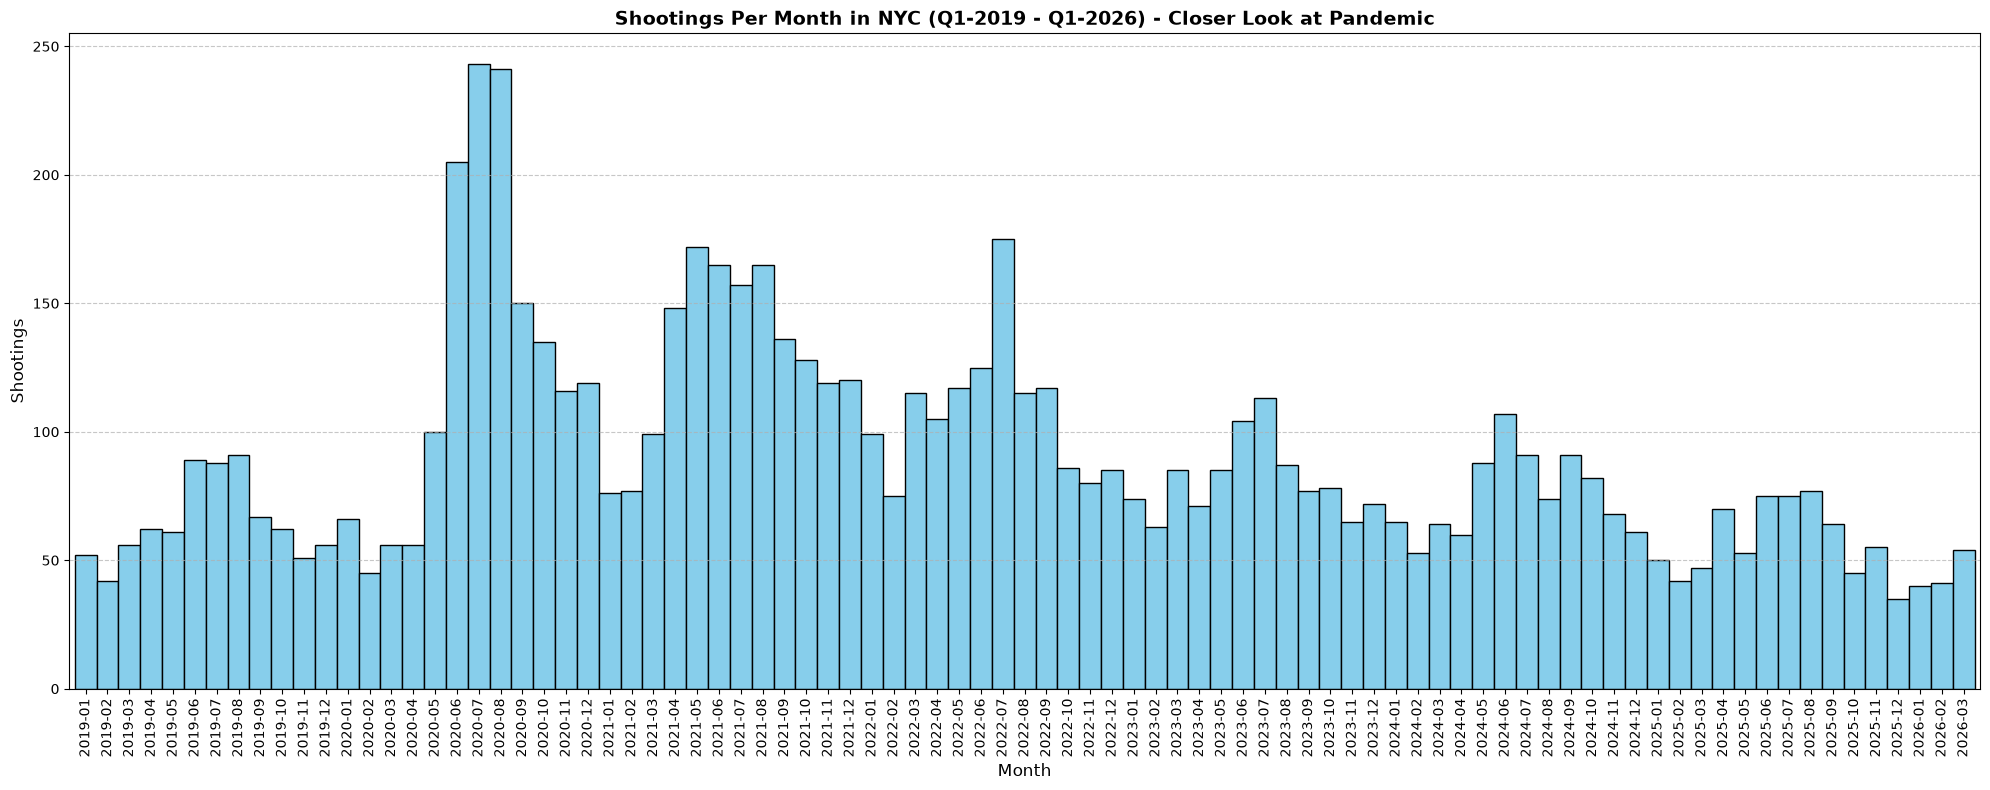

In [15]:
#Break down of shootings by month
mask = df_shootings['datetime'].between('2019-01-01', '2026-03-31')
shootings_per_month = df_shootings.loc[mask, 'datetime'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(20, 8))
shootings_per_month.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Month in NYC (Q1-2019 - Q1-2026) - Closer Look at Pandemic', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Shootings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

- Shootings totals appears stable prior to pandemic at just under 800 shootings city-wide per year from 2017 to 2019. 
- Shooting totals, city-wide per year, had spiked during 2020 (specifically Q3 after George Floyd's Murder) and didn't fall to pre-pandemic levels until 2025.
- According to Academic paper titled: **Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis** (https://pmc.ncbi.nlm.nih.gov/articles/PMC9095435/), increases in shootings were positively associated with the aftermath of the murder of George Floyd on 25th May 2020. But there was a “universal” (a negative association) across boroughs of shootings with an increase of both daily COVID-19 case counts and the NYS Pause stay-at-home order (the “shelter-in-place” order started on 22nd Mar 2020 and lasted just over 11 weeks until 8th Jun 2020)
- Also, the unrest following George Floyd’s murder resulted in a sizeable decline in shootings in Staten Island, But all other boroughs saw an increased shootings.
- While the effects of the initial NYC Pause were near universal across boroughs (decreased shootings), the unrest following George Floyd’s murder was associated with increased shootings across four of the five boroughs, while Staten Island had a sizeable decline.
- The academic paper: **Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis** only had data up to 30th Sep 2021 - The data here extends to 31st Mar 2026 so we can see the aftermath of pandemic and George Floyd's murder


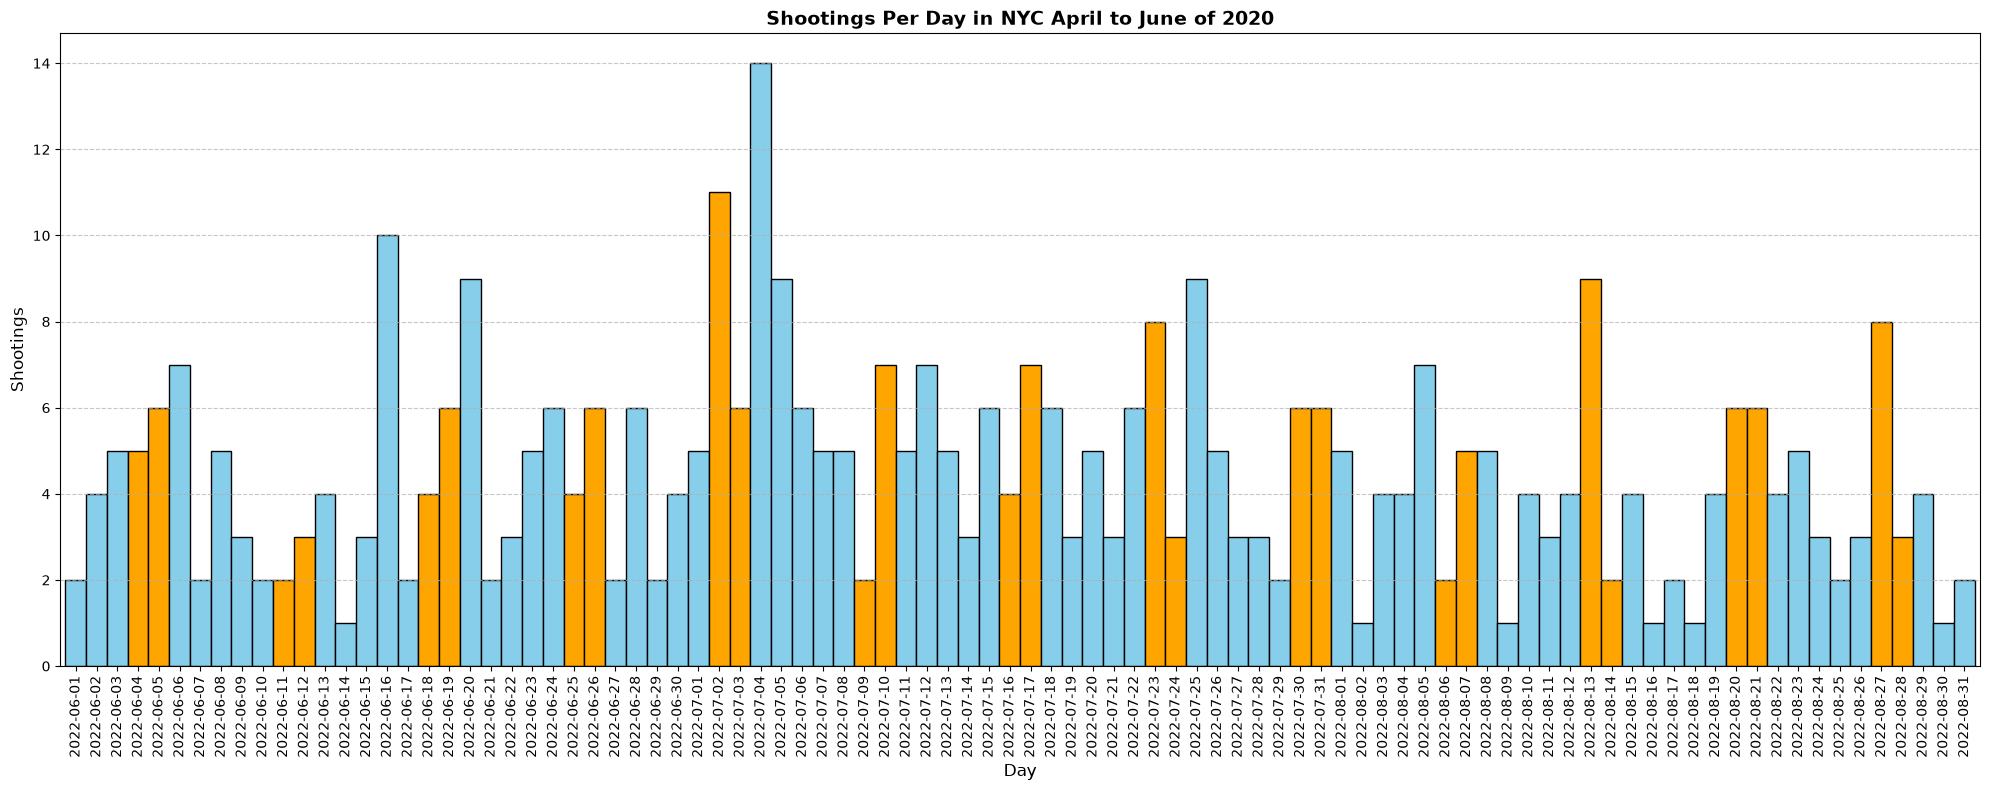

In [90]:
#Let's have a closer look at April to June of 2020 to see if shootings spiked after George Floyd's murder (25-May-2020)
mask = df_shootings['datetime'].between('2022-06-01 00:00:00', '2022-08-31 23:59:59')
shootings_per_day = df_shootings.loc[mask, 'datetime'].dt.to_period('D').value_counts().sort_index()

#colour weekends orange
bar_colors = ['orange' if d >= 5 else 'skyblue' for d in shootings_per_day.index.dayofweek]

plt.figure(figsize=(20, 8))
shootings_per_day.plot(kind='bar', width=1.0, color=bar_colors, edgecolor='black')

plt.title('Shootings Per Day in NYC April to June of 2020', fontsize=14, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Shootings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()